# Generate Figure 3: 30-minute BCHH seismo-acoustic record

This notebook replaces the original Antelope/dbpick screenshot with a reproducible Python figure.

Workflow:
1. Read the BCHH miniSEED files.
2. Trim the first 30 minutes after the SpaceX-video-derived explosion onset.
3. Remove instrument responses for the Nanometrics Centaur digitizer, Trillium/TCP seismometer, and infraBSU infrasound sensors using the same pattern as the Artemis 2 draft notebook.
4. Produce a custom multi-trace plot rather than using `Stream.plot()`.

The output is intended to become the revised manuscript Figure 3.

In [31]:
from pathlib import Path
import warnings

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.ticker import AutoMinorLocator

from obspy import read, Stream, UTCDateTime

# Optional but preferred: used for building response inventories from the NRL.
try:
    from flovopy.stationmetadata.build import NRL2inventory
except Exception as e:
    NRL2inventory = None
    warnings.warn(f"Could not import NRL2inventory from flovopy: {e}")

plt.rcParams.update({
    "font.size": 9,
    "axes.titlesize": 10,
    "axes.labelsize": 9,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "legend.fontsize": 8,
    "figure.dpi": 120,
})

## 1. Paths and event timing

`EXPLOSION_TIME` is the corrected onset time from the timestamped SpaceX video. The earlier synchronized YouTube-derived time was approximately 0.433 s early.

In [32]:
# -----------------------------------------------------------------------------
# User settings
# -----------------------------------------------------------------------------
MINISEED_DIR = Path('/Volumes/haldata/KSC/beforePASSCAL/EVENTS/20160901_SpaceXplosion')
OUTDIR = Path('/Users/thompsong/Library/CloudStorage/Box-Box/thompsong/3_Project_Documents/NASAprojects/201602_Rocket_Seismology/writing_papers_reports')
OUTDIR.mkdir(parents=True, exist_ok=True)

RAW_CACHE = OUTDIR / 'phase1234_raw.mseed'
CORRECTED_CACHE = OUTDIR / 'phase1234_corrected.mseed'

# SpaceX-video-derived initial visible rupture/onset time.
EXPLOSION_TIME = UTCDateTime('2016-09-01T13:07:12.066')

# Figure window: first 30 minutes after onset, with slight pre-event context.
PRE_EVENT_SEC = 180
POST_EVENT_SEC = 1800
PLOT_START = EXPLOSION_TIME - 150
PLOT_END = EXPLOSION_TIME + POST_EVENT_SEC

# Main annotated times. Update these if your video picks change.
EVENT_TIMES = {
    'Initial rupture': EXPLOSION_TIME,
    'Principal explosion': EXPLOSION_TIME + 4.0,
    'Payload impact': EXPLOSION_TIME + 17.0,   # placeholder; update from video if known
}

# Activity phases. Use UTCDateTime values here; these are intentionally easy to edit.
PHASES = [
    ('Phase I', EXPLOSION_TIME, EXPLOSION_TIME + 70),
    ('Phase II', UTCDateTime('2016-09-01T13:14:15'), UTCDateTime('2016-09-01T13:15:45')),
    ('Phase III', UTCDateTime('2016-09-01T13:19:12'), UTCDateTime('2016-09-01T13:25:00')),
    ('Phase IV', UTCDateTime('2016-09-01T13:29:54'), UTCDateTime('2016-09-01T13:34:54')),
]


TREMOR_START = UTCDateTime("2016-09-01T13:08:48")
TREMOR_END = UTCDateTime("2016-09-01T13:12:00")

# Desired plotting order. The code will use whatever matching traces are present.
CHANNEL_ORDER = ['HD1', 'HD2', 'HD3', 'HHE', 'HHN', 'HHZ']

## 2. Read raw BCHH data

The cache avoids rereading all day files repeatedly.

In [33]:
def read_bchh_stream(miniseed_dir: Path, cache_file: Path, starttime: UTCDateTime, endtime: UTCDateTime) -> Stream:
    """Read BCHH day files and cache the trimmed stream."""
    if cache_file.exists():
        st = read(str(cache_file))
    else:
        st = Stream()
        files = sorted(miniseed_dir.glob('*.20160901T000000'))
        if not files:
            # Fallback for normal miniSEED names.
            files = sorted(miniseed_dir.glob('*.mseed')) + sorted(miniseed_dir.glob('*.msd'))
        if not files:
            raise FileNotFoundError(f'No miniSEED files found in {miniseed_dir}')
        for fn in files:
            st += read(str(fn))
        st.trim(starttime, endtime)
        st.merge(method=1, fill_value='interpolate')
        st.write(str(cache_file), format='MSEED')
    return st

st_raw = read_bchh_stream(MINISEED_DIR, RAW_CACHE, EXPLOSION_TIME - PRE_EVENT_SEC, EXPLOSION_TIME + POST_EVENT_SEC)
st_raw.sort(keys=['station', 'channel'])
print(st_raw)
for tr in st_raw:
    print(tr.id, tr.stats.starttime, tr.stats.endtime, tr.stats.sampling_rate, tr.stats.npts)

6 Trace(s) in Stream:
FL.BCHH.00.HD1 | 2016-09-01T13:04:12.068000Z - 2016-09-01T13:37:12.064000Z | 250.0 Hz, 495000 samples
FL.BCHH.00.HD2 | 2016-09-01T13:04:12.068000Z - 2016-09-01T13:37:12.064000Z | 250.0 Hz, 495000 samples
FL.BCHH.00.HD3 | 2016-09-01T13:04:12.068000Z - 2016-09-01T13:37:12.064000Z | 250.0 Hz, 495000 samples
FL.BCHH.00.HHE | 2016-09-01T13:04:12.068000Z - 2016-09-01T13:37:12.064000Z | 250.0 Hz, 495000 samples
FL.BCHH.00.HHN | 2016-09-01T13:04:12.068000Z - 2016-09-01T13:37:12.064000Z | 250.0 Hz, 495000 samples
FL.BCHH.00.HHZ | 2016-09-01T13:04:12.068000Z - 2016-09-01T13:37:12.064000Z | 250.0 Hz, 495000 samples
FL.BCHH.00.HD1 2016-09-01T13:04:12.068000Z 2016-09-01T13:37:12.064000Z 250.0 495000
FL.BCHH.00.HD2 2016-09-01T13:04:12.068000Z 2016-09-01T13:37:12.064000Z 250.0 495000
FL.BCHH.00.HD3 2016-09-01T13:04:12.068000Z 2016-09-01T13:37:12.064000Z 250.0 495000
FL.BCHH.00.HHE 2016-09-01T13:04:12.068000Z 2016-09-01T13:37:12.064000Z 250.0 495000
FL.BCHH.00.HHN 2016-09-01T13:0

## 3. Instrument response removal

This follows the same logic used for the Artemis 2 draft processing:

- **Seismic channels** (`HHZ`, `HHN`, `HHE`) use Centaur + Trillium/TCP response and are output as ground velocity.
- **Infrasound channels** (`HD1`, `HD2`, `HD3`) use Centaur + infraBSU response and are output in pressure units using `output='DEF'`.

For the 2016 BCHH installation, the infrasound channels appear as `HD1/HD2/HD3` rather than the newer `DD0/DD1/DD2` convention. The helper below therefore identifies infrasound by channel name rather than by modern network naming.

In [34]:
def is_seismic_channel(channel: str) -> bool:
    return channel.upper() in {'HHE', 'HHN', 'HHZ', 'HH1', 'HH2'} or channel.upper().startswith('HH')


def is_infrasound_channel(channel: str) -> bool:
    ch = channel.upper()
    return ch in {'HD1', 'HD2', 'HD3', 'HDF', 'HD0', 'DD0', 'DD1', 'DD2', 'DDF'} or ch.startswith('HD') or ch.startswith('DD')


def build_centaur_inventory_for_trace(tr, sensor: str, vpp: float, units=None):
    """Build a minimal inventory for a single Centaur-recorded trace."""
    if NRL2inventory is None:
        raise ImportError('NRL2inventory is unavailable. Install/import flovopy or provide a StationXML inventory.')
    return NRL2inventory(
        nrl_path=None,
        net=tr.stats.network,
        sta=tr.stats.station,
        loc=tr.stats.location,
        chans=[tr.stats.channel],
        datalogger='Centaur',
        sensor=sensor,
        Vpp=vpp,
        fsamp=tr.stats.sampling_rate,
        lat=0.0,
        lon=0.0,
        elev=0.0,
        depth=0.0,
        sitename='',
        ondate=tr.stats.starttime,
        offdate=tr.stats.endtime,
        sensitivity=None,
        units=units,
    )


def remove_bchh_response(
    st: Stream,
    seismic_sensor: str = 'TCP',
    seismic_vpp: float = 40.0,
    infra_sensor: str = 'infrabsu',
    infra_vpp: float = 1.0,
    infra_extra_factor: float | None = None,
    water_level: float | None = None,
) -> Stream:
    """Return a response-corrected copy of the BCHH Stream.

    Parameters
    ----------
    st
        Raw waveform stream.
    seismic_sensor
        Sensor key passed to NRL2inventory. The Artemis 2 workflow used 'TCP'
        for Trillium Compact/Trillium-class seismometers.
    seismic_vpp
        Centaur full-scale voltage setting for the seismometer input.
    infra_sensor
        Sensor key passed to NRL2inventory. The Artemis 2 workflow used
        'infrabsu'.
    infra_vpp
        Centaur full-scale voltage setting for the infrasound inputs. Use 1.0
        if the infrasound channels were on the 1 Vpp Sensor B setting; use 40.0
        if this 2016 configuration used the same 40 Vpp setting as the seismic
        sensor.
    infra_extra_factor
        Optional post-removal multiplier. Artemis 2 used a calibration check
        against an expected factor of ~736 for infraBSU. Leave None unless you
        have confirmed the 2016 BCHH configuration needs the same correction.
    """
    out = Stream()
    for tr0 in st:
        tr = tr0.copy()
        ch = tr.stats.channel.upper()
        tr.detrend('linear')
        tr.taper(max_percentage=0.02)

        fs = float(tr.stats.sampling_rate)
        nyq = 0.5 * fs
        pre_filt = (0.01, 0.02, 0.94 * nyq, 0.98 * nyq)

        if is_seismic_channel(ch):
            inv = build_centaur_inventory_for_trace(
                tr, sensor=seismic_sensor, vpp=seismic_vpp, units=None
            )
            tr.remove_response(
                inventory=inv,
                output='VEL',
                pre_filt=pre_filt,
                zero_mean=True,
                taper=True,
                water_level=water_level,
            )
            tr.stats.units = 'm/s'
            tr.stats.processing_comment = f'Centaur + {seismic_sensor}; output=VEL'
            out += tr

        elif is_infrasound_channel(ch):
            inv = build_centaur_inventory_for_trace(
                tr, sensor=infra_sensor, vpp=infra_vpp, units='Pa'
            )
            tr.remove_response(
                inventory=inv,
                output='DEF',
                pre_filt=pre_filt,
                zero_mean=True,
                taper=True,
                water_level=water_level,
            )
            if infra_extra_factor is not None:
                tr.data = tr.data * infra_extra_factor
            tr.stats.units = 'Pa'
            tr.stats.processing_comment = f'Centaur + {infra_sensor}; output=DEF'
            out += tr

        else:
            warnings.warn(f'Skipping unrecognized channel {tr.id}')

    out.merge(method=1, fill_value='interpolate')
    out.sort(keys=['channel'])
    return out

# Reuse corrected cache if available. Delete the cache after changing response parameters.
if CORRECTED_CACHE.exists():
    st_corr = read(str(CORRECTED_CACHE))
else:
    st_corr = remove_bchh_response(
        st_raw,
        seismic_sensor='TCP',
        seismic_vpp=40.0,
        infra_sensor='infrabsu',
        infra_vpp=1.0,
        infra_extra_factor=None,
    )
    st_corr.trim(EXPLOSION_TIME - PRE_EVENT_SEC, EXPLOSION_TIME + POST_EVENT_SEC)
    st_corr.write(str(CORRECTED_CACHE), format='MSEED')

print(st_corr)
for tr in st_corr:
    print(tr.id, getattr(tr.stats, 'units', ''), getattr(tr.stats, 'processing_comment', ''))

6 Trace(s) in Stream:
FL.BCHH.00.HD1 | 2016-09-01T13:04:12.068000Z - 2016-09-01T13:37:12.064000Z | 250.0 Hz, 495000 samples
FL.BCHH.00.HD2 | 2016-09-01T13:04:12.068000Z - 2016-09-01T13:37:12.064000Z | 250.0 Hz, 495000 samples
FL.BCHH.00.HD3 | 2016-09-01T13:04:12.068000Z - 2016-09-01T13:37:12.064000Z | 250.0 Hz, 495000 samples
FL.BCHH.00.HHE | 2016-09-01T13:04:12.068000Z - 2016-09-01T13:37:12.064000Z | 250.0 Hz, 495000 samples
FL.BCHH.00.HHN | 2016-09-01T13:04:12.068000Z - 2016-09-01T13:37:12.064000Z | 250.0 Hz, 495000 samples
FL.BCHH.00.HHZ | 2016-09-01T13:04:12.068000Z - 2016-09-01T13:37:12.064000Z | 250.0 Hz, 495000 samples
FL.BCHH.00.HD1  
FL.BCHH.00.HD2  
FL.BCHH.00.HD3  
FL.BCHH.00.HHE  
FL.BCHH.00.HHN  
FL.BCHH.00.HHZ  


## 4. Prepare plotting stream

For the overview figure, we apply only light cleanup after response removal. The goal is to preserve the true chronology and relative character while preventing a single spike from making the later phases invisible.

In [35]:
def select_channels_in_order(st: Stream, channel_order) -> Stream:
    selected = Stream()
    for ch in channel_order:
        matches = st.select(channel=ch)
        if len(matches) == 0:
            # Some miniSEED files may have location-code variants or nonstandard names.
            matches = Stream([tr for tr in st if tr.stats.channel.upper() == ch.upper()])
        if len(matches):
            selected += matches[0].copy()
        else:
            warnings.warn(f'No trace found for channel {ch}')
    return selected


def preprocess_for_overview(st: Stream, starttime: UTCDateTime, endtime: UTCDateTime) -> Stream:
    """Trim, detrend, and lightly filter the corrected stream for plotting."""
    out = Stream()
    for tr0 in st:
        tr = tr0.copy()
        tr.trim(starttime, endtime, pad=True, fill_value=0.0)
        tr.detrend('linear')
        tr.taper(max_percentage=0.005)
        fs = tr.stats.sampling_rate
        nyq = 0.5 * fs
        ch = tr.stats.channel.upper()
        if is_infrasound_channel(ch):
            # Preserve low-frequency pressure signal while suppressing drift.
            #tr.filter('bandpass', freqmin=0.02, freqmax=min(80.0, 0.45 * nyq), corners=2, zerophase=True)
            tr.filter('bandpass', freqmin=0.05, freqmax=min(200.0, 0.45 * nyq), corners=2, zerophase=True)
        elif is_seismic_channel(ch):
            # Velocity overview; low cut removes long-period drift after response removal.
            #tr.filter('bandpass', freqmin=0.05, freqmax=min(80.0, 0.45 * nyq), corners=2, zerophase=True)
            tr.filter('bandpass', freqmin=0.05, freqmax=min(200.0, 0.45 * nyq), corners=2, zerophase=True)
        out += tr
    return out

st_plot = select_channels_in_order(st_corr, CHANNEL_ORDER)
st_plot = preprocess_for_overview(st_plot, PLOT_START, PLOT_END)
print(st_plot)

6 Trace(s) in Stream:
FL.BCHH.00.HD1 | 2016-09-01T13:04:42.068000Z - 2016-09-01T13:37:12.068000Z | 250.0 Hz, 487501 samples
FL.BCHH.00.HD2 | 2016-09-01T13:04:42.068000Z - 2016-09-01T13:37:12.068000Z | 250.0 Hz, 487501 samples
FL.BCHH.00.HD3 | 2016-09-01T13:04:42.068000Z - 2016-09-01T13:37:12.068000Z | 250.0 Hz, 487501 samples
FL.BCHH.00.HHE | 2016-09-01T13:04:42.068000Z - 2016-09-01T13:37:12.068000Z | 250.0 Hz, 487501 samples
FL.BCHH.00.HHN | 2016-09-01T13:04:42.068000Z - 2016-09-01T13:37:12.068000Z | 250.0 Hz, 487501 samples
FL.BCHH.00.HHZ | 2016-09-01T13:04:42.068000Z - 2016-09-01T13:37:12.068000Z | 250.0 Hz, 487501 samples


## 5. Custom publication plot

This replaces `Stream.plot()` so that the figure style, channel labels, scaling, annotations, and exported file sizes are fully controlled.

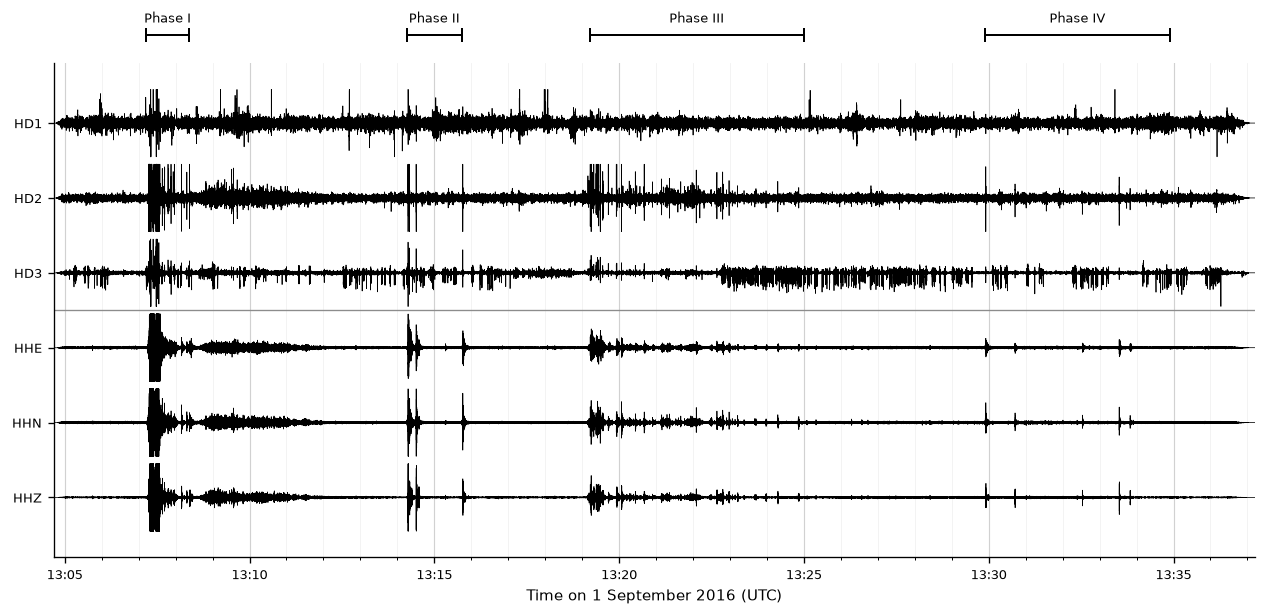

In [36]:
def trace_time_array_datetime64(tr):
    """Return matplotlib datetimes for trace samples."""
    t0 = tr.stats.starttime.datetime
    sr = float(tr.stats.sampling_rate)
    seconds = np.arange(tr.stats.npts, dtype=float) / sr
    return mdates.date2num(t0) + seconds / 86400.0


def robust_scale(data, percentile=99.5):
    x = np.asarray(data, dtype=float)
    x = x[np.isfinite(x)]
    if x.size == 0:
        return 1.0
    s = np.percentile(np.abs(x), percentile)
    return s if s > 0 else 1.0


def add_time_bar(ax, t0, t1, y, text, above=True, lw=1.2):
    x0 = mdates.date2num(t0.datetime)
    x1 = mdates.date2num(t1.datetime)
    ax.plot([x0, x1], [y, y], color='black', lw=lw, clip_on=False, zorder=20)
    tick = 0.08
    ax.plot([x0, x0], [y - tick, y + tick], color='black', lw=lw, clip_on=False, zorder=20)
    ax.plot([x1, x1], [y - tick, y + tick], color='black', lw=lw, clip_on=False, zorder=20)
    ax.text((x0 + x1) / 2, y + (0.12 if above else -0.12), text,
            ha='center', va='bottom' if above else 'top', fontsize=8,
            bbox=dict(facecolor='white', edgecolor='none', alpha=0.85, pad=1.0),
            clip_on=False, zorder=25)


def make_overview_figure(
    st: Stream,
    outfile_base: Path,
    plot_start: UTCDateTime,
    plot_end: UTCDateTime,
    event_times: dict,
    phases: list,
    normalize_by_group: bool = True,
    clip: float = 3.0,
):
    n = len(st)
    if n == 0:
        raise ValueError('No traces to plot')

    fig, ax = plt.subplots(figsize=(11.0, 5.8))

    offsets = np.arange(n)[::-1].astype(float)
    channel_labels = []

    # Separate robust scaling for pressure and seismic velocity, so later phases are visible.
    infra_scales = []
    seis_scales = []
    for tr in st:
        s = robust_scale(tr.data, percentile=99.3)
        if is_infrasound_channel(tr.stats.channel):
            infra_scales.append(s)
        else:
            seis_scales.append(s)
    group_scale_infra = np.median(infra_scales) if infra_scales else 1.0
    group_scale_seis = np.median(seis_scales) if seis_scales else 1.0

    for i, tr in enumerate(st):
        y0 = offsets[i]
        ch = tr.stats.channel.upper()
        t = trace_time_array_datetime64(tr)
        data = tr.data.astype(float)
        data = np.nan_to_num(data, nan=0.0, posinf=0.0, neginf=0.0)

        if normalize_by_group:
            scale = group_scale_infra if is_infrasound_channel(ch) else group_scale_seis
        else:
            scale = robust_scale(data, percentile=99.3)
        if not np.isfinite(scale) or scale <= 0:
            scale = 1.0

        y = y0 + np.clip(data / scale, -clip, clip) * 0.15
        ax.plot(t, y, '-', color='black', lw=0.45, rasterized=True)

        if is_infrasound_channel(ch):
            label = ch
        else:
            label = ch
        channel_labels.append(label)

    ax.set_yticks(offsets)
    ax.set_yticklabels(channel_labels)
    ax.set_ylim(-0.8, n - 0.2)

    ax.set_xlim(mdates.date2num(plot_start.datetime), mdates.date2num(plot_end.datetime))
    ax.xaxis.set_major_locator(mdates.MinuteLocator(byminute=range(0, 60, 5)))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
    ax.xaxis.set_minor_locator(mdates.MinuteLocator(interval=1))
    ax.grid(axis='x', which='major', color='0.82', lw=0.7)
    ax.grid(axis='x', which='minor', color='0.93', lw=0.4)
    ax.set_xlabel('Time on 1 September 2016 (UTC)')

    # Thin separator between infrasound and seismic groups.
    if n >= 6:
        ax.axhline(2.5, color='0.55', lw=0.8)
        '''
        label_date = plot_start + 300
        ax.text(mdates.date2num(label_date.datetime), 5.5, 'Infrasound', ha='left', va='center', fontsize=11,
                bbox=dict(facecolor='white', edgecolor='none', alpha=0.8, pad=1))
        ax.text(mdates.date2num(label_date.datetime), 2.3, 'Seismic velocity', ha='left', va='center', fontsize=11,
                bbox=dict(facecolor='white', edgecolor='none', alpha=0.8, pad=1))
        '''

    '''
    # Mark principal video-timed events.
    event_y = n - 0.25
    for name, tt in event_times.items():
        x = mdates.date2num(tt.datetime)
        ax.axvline(x, color='black', lw=0.9, ls='-', alpha=0.65, zorder=10)
        ax.annotate(name, xy=(x, event_y - 0.05), xytext=(x, event_y + 0.45),
                    ha='center', va='bottom', fontsize=7, rotation=90,
                    arrowprops=dict(arrowstyle='-', color='black', lw=0.7),
                    clip_on=False)
    '''

    # Phase bars above traces.
    phase_y = n + 0.18
    for name, t0, t1 in phases:
        # Only plot phase bars that overlap the displayed window.
        if t1 < plot_start or t0 > plot_end:
            continue
        t0c = max(t0, plot_start)
        t1c = min(t1, plot_end)
        add_time_bar(ax, t0c, t1c, phase_y, name, above=True)
        #phase_y += 0.22 if name == 'Phase I' else 0.0

    '''
    ax.text(0.01, 1.02, '30-minute BCHH seismo-acoustic record', transform=ax.transAxes,
            ha='left', va='bottom', fontsize=10, fontweight='bold')

    # Add small scale notes rather than crowded y-axis units.
    scale_note = 'Traces are response-corrected and robustly scaled for display; clipped at ±{:.0f} display units.'.format(clip)
    ax.text(0.99, 0.01, scale_note, transform=ax.transAxes, ha='right', va='bottom', fontsize=7,
            bbox=dict(facecolor='white', edgecolor='none', alpha=0.75, pad=1.0))
    '''

    for spine in ['top', 'right']:
        ax.spines[spine].set_visible(False)

    fig.subplots_adjust(left=0.08, right=0.99, top=0.84, bottom=0.13)

    for ext in ['png', 'pdf']:
        fig.savefig(outfile_base.with_suffix(f'.{ext}'), dpi=300, bbox_inches='tight', pad_inches=0.04)
    return fig, ax


st_plot2 = st_plot.copy()
st_plot2.detrend("demean")
st_plot2.detrend("linear")
st_plot2.taper(max_percentage=0.01)

for tr in st_plot2:
    if is_infrasound_channel(tr.stats.channel):
        tr.filter("bandpass", freqmin=0.5, freqmax=20.0, corners=4, zerophase=True)
    else:
        tr.filter("bandpass", freqmin=1.0, freqmax=25.0, corners=4, zerophase=True)

fig, ax = make_overview_figure(
    st_plot2,
    OUTDIR / 'fig03_bchh_30min_overview',
    PLOT_START,
    PLOT_END,
    EVENT_TIMES,
    PHASES,
    normalize_by_group=False,
    clip=3.0,
)
plt.show()

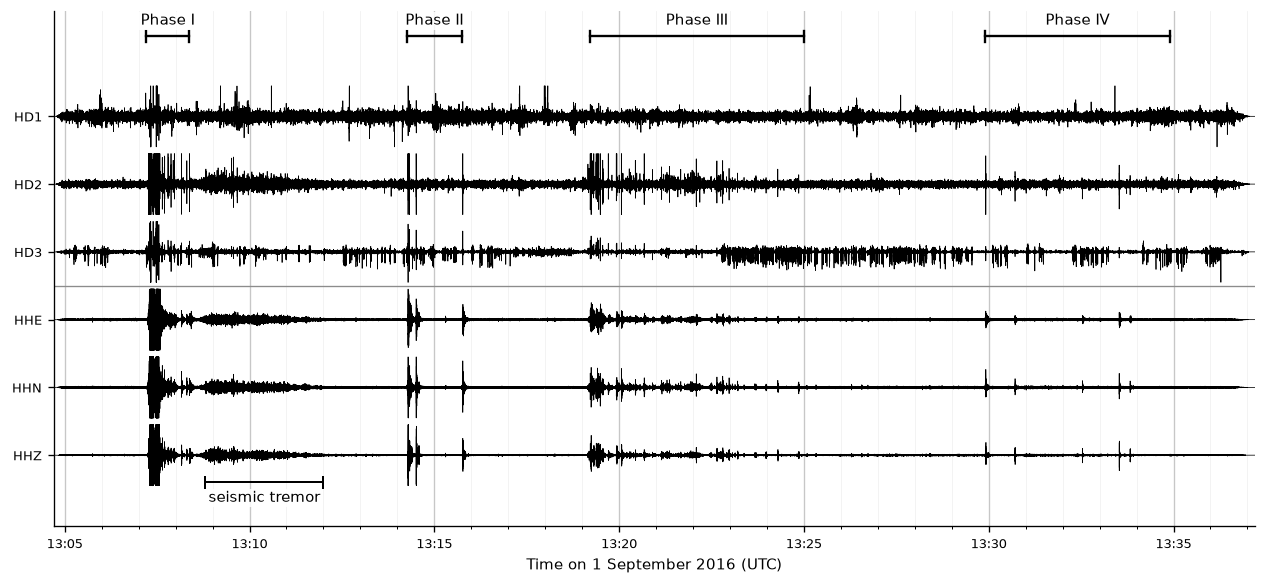

In [40]:
def trace_time_array_datetime64(tr):
    """Return matplotlib date numbers for trace samples."""
    t0 = tr.stats.starttime.datetime
    sr = float(tr.stats.sampling_rate)
    seconds = np.arange(tr.stats.npts, dtype=float) / sr
    return mdates.date2num(t0) + seconds / 86400.0


def robust_scale(data, percentile=99.3):
    """Robust absolute-amplitude scale for display."""
    x = np.asarray(data, dtype=float)
    x = x[np.isfinite(x)]
    if x.size == 0:
        return 1.0
    s = np.percentile(np.abs(x), percentile)
    return s if np.isfinite(s) and s > 0 else 1.0


def add_time_bar(ax, t0, t1, y, text, above=True, lw=1.4, fontsize=9):
    """Draw a bracket-style time interval."""
    x0 = mdates.date2num(t0.datetime)
    x1 = mdates.date2num(t1.datetime)

    ax.plot([x0, x1], [y, y], color="black", lw=lw, clip_on=False, zorder=20)

    tick = 0.08
    ax.plot([x0, x0], [y - tick, y + tick], color="black", lw=lw, clip_on=False, zorder=20)
    ax.plot([x1, x1], [y - tick, y + tick], color="black", lw=lw, clip_on=False, zorder=20)

    dy = 0.12 if above else -0.12
    va = "bottom" if above else "top"

    ax.text(
        (x0 + x1) / 2,
        y + dy,
        text,
        ha="center",
        va=va,
        fontsize=fontsize,
        bbox=dict(facecolor="white", edgecolor="none", alpha=0.85, pad=1.0),
        clip_on=False,
        zorder=25,
    )


def make_overview_figure(
    st: Stream,
    outfile_base: Path,
    plot_start: UTCDateTime,
    plot_end: UTCDateTime,
    phases: list,
    explosion_time: UTCDateTime,
    tremor_start: UTCDateTime | None = None,
    tremor_end: UTCDateTime | None = None,
    normalize_by_group: bool = False,
    clip: float = 3.0,
    trace_gain: float = 0.15,
):
    """
    Make 30-minute BCHH overview figure.

    Phase I is forced to start at explosion_time.
    Phase bars are interpreted as infrasound-defined intervals.
    Tremor bar is an optional seismic-only annotation.
    """
    n = len(st)
    if n == 0:
        raise ValueError("No traces to plot")

    fig, ax = plt.subplots(figsize=(11.0, 5.8))

    offsets = np.arange(n)[::-1].astype(float)
    channel_labels = []

    infra_scales, seis_scales = [], []
    for tr in st:
        s = robust_scale(tr.data, percentile=99.3)
        if is_infrasound_channel(tr.stats.channel):
            infra_scales.append(s)
        else:
            seis_scales.append(s)

    group_scale_infra = np.median(infra_scales) if infra_scales else 1.0
    group_scale_seis = np.median(seis_scales) if seis_scales else 1.0

    for i, tr in enumerate(st):
        y0 = offsets[i]
        ch = tr.stats.channel.upper()

        t = trace_time_array_datetime64(tr)
        data = tr.data.astype(float)
        data = np.nan_to_num(data, nan=0.0, posinf=0.0, neginf=0.0)

        if normalize_by_group:
            scale = group_scale_infra if is_infrasound_channel(ch) else group_scale_seis
        else:
            scale = robust_scale(data, percentile=99.3)

        if not np.isfinite(scale) or scale <= 0:
            scale = 1.0

        y = y0 + np.clip(data / scale, -clip, clip) * trace_gain
        ax.plot(t, y, "-", color="black", lw=0.45, rasterized=True)

        channel_labels.append(ch)

    ax.set_yticks(offsets)
    ax.set_yticklabels(channel_labels)

    # Extra bottom space for seismic tremor annotation; top space for phase bars.
    ax.set_ylim(-1.05, n + 0.55)

    ax.set_xlim(
        mdates.date2num(plot_start.datetime),
        mdates.date2num(plot_end.datetime),
    )
    ax.xaxis.set_major_locator(mdates.MinuteLocator(byminute=range(0, 60, 5)))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
    ax.xaxis.set_minor_locator(mdates.MinuteLocator(interval=1))
    ax.grid(axis="x", which="major", color="0.78", lw=0.8)
    ax.grid(axis="x", which="minor", color="0.93", lw=0.4)
    ax.set_xlabel("Time on 1 September 2016 (UTC)")

    # Thin separator between infrasound and seismic channels.
    if n >= 6:
        ax.axhline(2.5, color="0.55", lw=0.8)

    # Phase bars above traces. Force Phase I onset to EXPLOSION_TIME.
    phase_y = n + 0.18
    for name, t0, t1 in phases:
        if name.strip().lower() == "phase i":
            t0 = explosion_time

        if t1 < plot_start or t0 > plot_end:
            continue

        add_time_bar(
            ax,
            max(t0, plot_start),
            min(t1, plot_end),
            phase_y,
            name,
            above=True,
            lw=1.4,
            fontsize=9,
        )

    # Optional seismic tremor/coda annotation below seismic traces.
    if tremor_start is not None and tremor_end is not None:
        if tremor_end >= plot_start and tremor_start <= plot_end:
            add_time_bar(
                ax,
                max(tremor_start, plot_start),
                min(tremor_end, plot_end),
                y=-0.4,
                text="seismic tremor",
                above=False,
                lw=1.2,
                fontsize=9,
            )

    for spine in ["top", "right"]:
        ax.spines[spine].set_visible(False)

    fig.subplots_adjust(left=0.08, right=0.99, top=0.88, bottom=0.14)

    for ext in ["png", "pdf"]:
        fig.savefig(
            outfile_base.with_suffix(f".{ext}"),
            dpi=300,
            bbox_inches="tight",
            pad_inches=0.04,
        )

    return fig, ax


# Display filtering only; quantitative amplitudes should use unfiltered/unclipped data.
st_plot2 = st_plot.copy()
st_plot2.detrend("demean")
st_plot2.detrend("linear")
st_plot2.taper(max_percentage=0.01)

for tr in st_plot2:
    if is_infrasound_channel(tr.stats.channel):
        tr.filter("bandpass", freqmin=0.5, freqmax=20.0, corners=4, zerophase=True)
    else:
        tr.filter("bandpass", freqmin=1.0, freqmax=25.0, corners=4, zerophase=True)





fig, ax = make_overview_figure(
    st_plot2,
    OUTDIR / "fig03_bchh_30min_overview",
    PLOT_START,
    PLOT_END,
    phases=PHASES,
    explosion_time=EXPLOSION_TIME,
    tremor_start=TREMOR_START,
    tremor_end=TREMOR_END,
    normalize_by_group=False,
    clip=3.0,
    trace_gain=0.15,
)

plt.show()

## 6. Quick diagnostic: corrected amplitudes

Use this to verify that the response removal produced plausible values before using the figure in the manuscript.

In [38]:
rows = []
for tr in st_plot:
    x = np.asarray(tr.data, dtype=float)
    rows.append({
        'id': tr.id,
        'channel': tr.stats.channel,
        'units': getattr(tr.stats, 'units', ''),
        'sampling_rate': tr.stats.sampling_rate,
        'min': float(np.nanmin(x)),
        'max': float(np.nanmax(x)),
        'p99_abs': float(np.nanpercentile(np.abs(x), 99)),
        'p99_9_abs': float(np.nanpercentile(np.abs(x), 99.9)),
    })

try:
    import pandas as pd
    display(pd.DataFrame(rows))
except Exception:
    for r in rows:
        print(r)

,id,channel,units,sampling_rate,min,max,p99_abs,p99_9_abs
0,FL.BCHH.00.HD1,HD1,,250.0,-0.105855,0.581399,0.036451,0.060438
1,FL.BCHH.00.HD2,HD2,,250.0,-0.007967,0.057922,0.000444,0.001695
2,FL.BCHH.00.HD3,HD3,,250.0,-0.123427,0.770461,0.022788,0.037023
3,FL.BCHH.00.HHE,HHE,,250.0,-0.001068,0.000958,0.000033,0.000188
4,FL.BCHH.00.HHN,HHN,,250.0,-0.002163,0.001817,0.000043,0.000297
5,FL.BCHH.00.HHZ,HHZ,,250.0,-0.002874,0.002198,0.000057,0.000480


## 7. Manuscript caption draft

**Figure 3.** Continuous infrasound (upper three traces) and three-component seismic velocity (lower three traces) recordings from the BCHH seismo-acoustic array during the first 30 minutes following the initial Falcon 9 explosion on 1 September 2016. The initial rupture time is taken from the timestamped SpaceX video. The principal explosion, payload impact, and subsequent phases of activity are indicated. Traces are response-corrected and robustly scaled for display.


Figure 3. Continuous response-corrected infrasound (HD1–HD3) and three-component seismic velocity (HHE, HHN, HHZ) recordings from the BCHH seismo-acoustic array during the first 30 minutes following the initial Falcon 9 explosion. The four principal phases of activity identified in this study are indicated. Traces are independently scaled for display and clipped to emphasize lower-amplitude activity following the principal explosion.

Phase I 2016-09-01T13:07:12.066000Z 2016-09-01T13:08:22.066000Z 0.7844333333333329 32
Phase II 2016-09-01T13:14:15.000000Z 2016-09-01T13:15:45.000000Z 0.0 24
Phase III 2016-09-01T13:19:12.000000Z 2016-09-01T13:25:00.000000Z 0.1 17
Phase IV 2016-09-01T13:29:54.000000Z 2016-09-01T13:34:54.000000Z 0.4 7
Phase I 2016-09-01T13:07:12.066000Z 2016-09-01T13:08:22.066000Z 0.7844333333333329 32
Phase II 2016-09-01T13:14:15.000000Z 2016-09-01T13:15:45.000000Z 0.0 24
Phase III 2016-09-01T13:19:12.000000Z 2016-09-01T13:25:00.000000Z 0.1 17
Phase IV 2016-09-01T13:29:54.000000Z 2016-09-01T13:34:54.000000Z 0.4 7


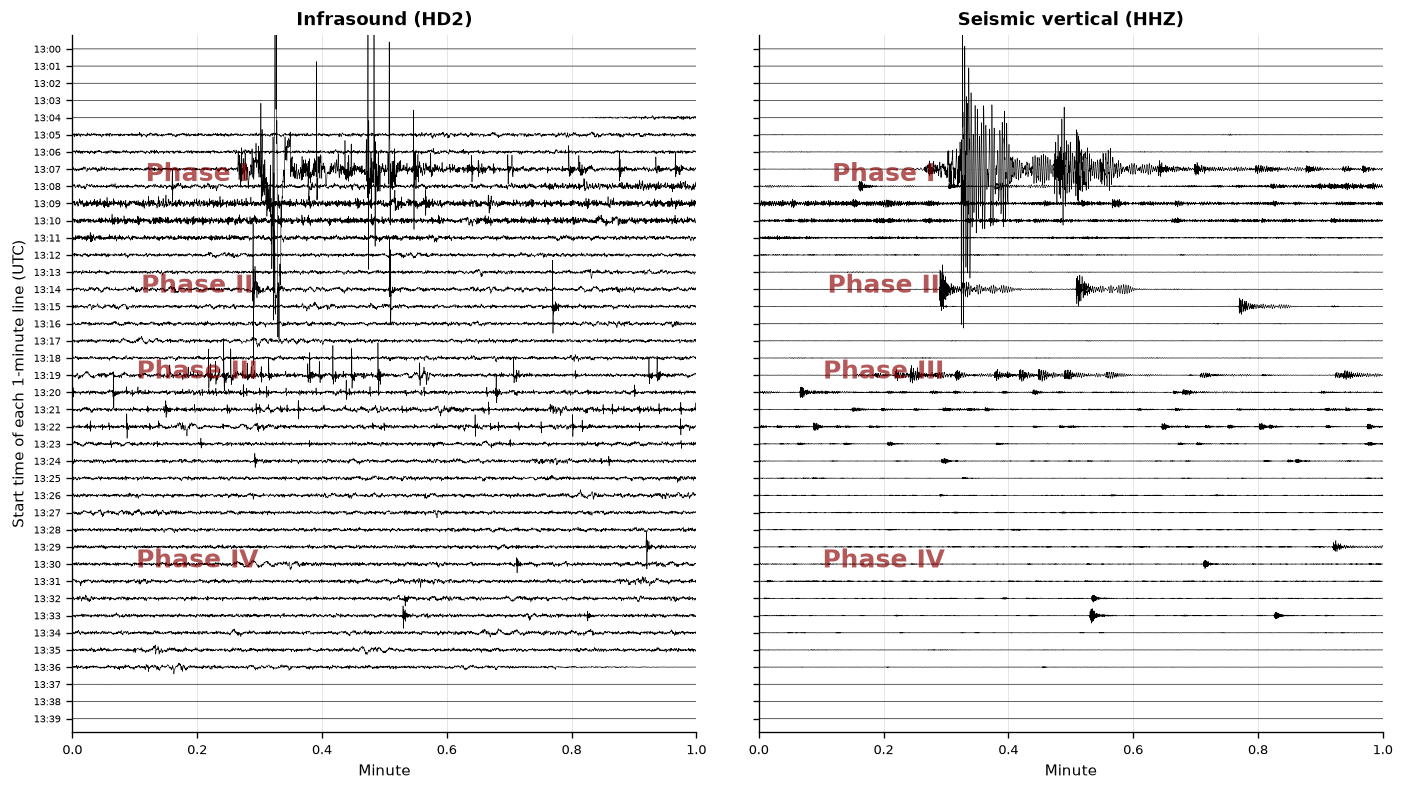

In [39]:
def make_helicorder_panel(
    tr,
    ax,
    start,
    end,
    minutes_per_line=1,
    scale_percentile=99.5,
    trace_gain=0.35,
    clip=3.0,
    title=None,
):
    """
    Custom helicorder-style plot: one horizontal line per minute.
    """
    tr = tr.copy().trim(start, end, pad=True, fill_value=0)
    sr = float(tr.stats.sampling_rate)
    samples_per_line = int(minutes_per_line * 60 * sr)
    n_lines = int(np.ceil((end - start) / (minutes_per_line * 60)))

    scale = robust_scale(tr.data, percentile=scale_percentile)

    for i in range(n_lines):
        line_start = start + i * minutes_per_line * 60
        idx0 = int(round((line_start - tr.stats.starttime) * sr))
        idx1 = idx0 + samples_per_line

        if idx0 < 0 or idx0 >= tr.stats.npts:
            continue

        data = tr.data[max(idx0, 0):min(idx1, tr.stats.npts)].astype(float)
        if data.size == 0:
            continue

        if data.size < samples_per_line:
            data = np.pad(data, (0, samples_per_line - data.size), mode="constant")

        x = np.linspace(0, minutes_per_line, samples_per_line, endpoint=False)
        y0 = n_lines - 1 - i
        y = y0 + np.clip(data / scale, -clip, clip) * trace_gain

        ax.plot(x, y, color="black", lw=0.35, rasterized=True)

    ax.set_xlim(0, minutes_per_line)
    ax.set_ylim(-0.8, n_lines - 0.2)

    yticks = np.arange(n_lines)
    ylabels = []
    for y in yticks:
        i = n_lines - 1 - y
        tt = start + i * minutes_per_line * 60
        ylabels.append(tt.strftime("%H:%M"))

    ax.set_yticks(yticks)
    ax.set_yticklabels(ylabels, fontsize=6)
    ax.set_xlabel("Minute")
    ax.set_title(title or tr.id, fontsize=11, fontweight="bold")

    ax.grid(axis="x", color="0.88", lw=0.5)
    ax.grid(axis="y", color="0.92", lw=0.4)

    for spine in ["top", "right"]:
        ax.spines[spine].set_visible(False)


def add_phase_spans_to_helicorder(ax, phases, start, minutes_per_line=1):
    """
    Mark phase intervals on a helicorder-style plot.
    Approximate: draws phase labels at the relevant line and x-position.
    """
    n_lines = int(np.ceil((PLOT_END - start) / (minutes_per_line * 60)))

    for name, t0, t1 in phases:
        if name.strip().lower() == "phase i":
            t0 = EXPLOSION_TIME

        if t1 < start or t0 > PLOT_END:
            continue

        mid = t0 + 0.5 * (t1 - t0)
        elapsed = mid - start
        line_index = int(elapsed // (minutes_per_line * 60))
        x = (elapsed % (minutes_per_line * 60)) / 60.0
        y = n_lines - 1 - line_index + 0.38

        ax.text(
            x,
            y,
            name,
            ha="center",
            va="bottom",
            fontsize=9,
            fontweight="bold",
            bbox=dict(facecolor="white", edgecolor="none", alpha=0.75, pad=1.0),
            zorder=30,
        )


def make_helicorder_figure(
    st,
    outfile_base,
    start,
    end,
    infra_channel="HD2",
    seis_channel="HHZ",
    minutes_per_line=1,
):
    st_h = st.copy().trim(start, end)

    infra = st_h.select(channel=infra_channel)
    seis = st_h.select(channel=seis_channel)

    if len(infra) == 0:
        raise ValueError(f"No trace found for {infra_channel}")
    if len(seis) == 0:
        raise ValueError(f"No trace found for {seis_channel}")

    fig, axes = plt.subplots(
        1, 2,
        figsize=(12.0, 7.0),
        sharey=True,
        gridspec_kw={"wspace": 0.10},
    )

    make_helicorder_panel(
        infra[0],
        axes[0],
        start,
        end,
        minutes_per_line=minutes_per_line,
        scale_percentile=99.5,
        trace_gain=0.34,
        clip=100.0,
        title=f"Infrasound ({infra_channel})",
    )

    make_helicorder_panel(
        seis[0],
        axes[1],
        start,
        end,
        minutes_per_line=minutes_per_line,
        scale_percentile=99.5,
        trace_gain=0.34,
        clip=100.0,
        title=f"Seismic vertical ({seis_channel})",
    )

    #add_phase_spans_to_helicorder(axes[0], PHASES, start, minutes_per_line)
    #add_phase_spans_to_helicorder(axes[1], PHASES, start, minutes_per_line)
    add_phase_spans_to_helicorder(
        axes[0], PHASES, start=start, end=end, minutes_per_line=minutes_per_line
    )
    add_phase_spans_to_helicorder(
        axes[1], PHASES, start=start, end=end, minutes_per_line=minutes_per_line
    )

    axes[0].set_ylabel("Start time of each 1-minute line (UTC)")
    axes[1].tick_params(labelleft=False)
    '''
    fig.suptitle(
        "BCHH helicorder-style records, 13:00–13:40 UTC",
        fontsize=13,
        fontweight="bold",
        y=0.96,
    )
    '''

    fig.subplots_adjust(left=0.08, right=0.99, bottom=0.08, top=0.91)

    for ext in ["png", "pdf"]:
        fig.savefig(
            outfile_base.with_suffix(f".{ext}"),
            dpi=300,
            bbox_inches="tight",
            pad_inches=0.04,
        )

    return fig, axes

def add_phase_spans_to_helicorder(
    ax,
    phases,
    start,
    end,
    minutes_per_line=1,
    color="darkred",
    alpha=0.65,
):
    """
    Draw phase labels on a helicorder.
    Labels are placed near the middle of each phase.
    """

    n_lines = int(np.ceil((end - start) / (minutes_per_line * 60)))
    manual_positions = {
        "Phase I":  (0.2, 31.5),
        "Phase II": (0.2, 25.0),
        "Phase III":(0.20, 20.0),
        "Phase IV": (0.2, 9.0),
    }

    for name, t0, t1 in phases:

        if name.lower().strip() == "phase i":
            t0 = EXPLOSION_TIME

        if t1 < start or t0 > end:
            continue

        mid = t0 + 0.5 * (t1 - t0)

        elapsed = float(mid - start)

        line = int(elapsed // (minutes_per_line * 60))
        line = np.clip(line, 0, n_lines - 1)

        x = (elapsed % (minutes_per_line * 60)) / 60.0
        y = n_lines - 1 - line

        print(name, t0, t1, x, y)

        if name in manual_positions:
            x, y = manual_positions[name]

        # Offset slightly above trace centre
        y += 0.18

        ax.text(
            x,
            y,
            name,
            fontsize=15,
            fontweight="bold",
            color=color,
            alpha=alpha,
            ha="center",
            va="center",
            zorder=100,
        )


HELI_START = UTCDateTime("2016-09-01T13:00:00")
HELI_END = UTCDateTime("2016-09-01T13:40:00")

fig, axes = make_helicorder_figure(
    st_plot2,
    OUTDIR / "figS_helicorder_bchh_1340",
    HELI_START,
    HELI_END,
    infra_channel="HD2",
    seis_channel="HHZ",
    minutes_per_line=1,
)

plt.show()

In [ ]:
def make_zoom_figure(
    st: Stream,
    outfile_base: Path,
    zoom_start: UTCDateTime,
    zoom_end: UTCDateTime,
    event_times: dict | None = None,
    normalize_by_group: bool = False,
    clip: float = 4.0,
    trace_gain: float = 0.18,
):
    """
    Expanded view of the first ~20 s of the Falcon 9 explosion sequence.
    Uses the same plotting style as the 30-minute overview figure.
    """
    n = len(st)
    if n == 0:
        raise ValueError("No traces to plot")

    fig, ax = plt.subplots(figsize=(11.0, 5.2))

    offsets = np.arange(n)[::-1].astype(float)
    channel_labels = []

    infra_scales, seis_scales = [], []
    for tr in st:
        s = robust_scale(tr.data, percentile=99.5)
        if is_infrasound_channel(tr.stats.channel):
            infra_scales.append(s)
        else:
            seis_scales.append(s)

    group_scale_infra = np.median(infra_scales) if infra_scales else 1.0
    group_scale_seis = np.median(seis_scales) if seis_scales else 1.0

    for i, tr in enumerate(st):
        y0 = offsets[i]
        ch = tr.stats.channel.upper()

        trc = tr.copy().trim(zoom_start, zoom_end, pad=True, fill_value=0)
        t = trace_time_array_datetime64(trc)

        data = trc.data.astype(float)
        data = np.nan_to_num(data, nan=0.0, posinf=0.0, neginf=0.0)

        if normalize_by_group:
            scale = group_scale_infra if is_infrasound_channel(ch) else group_scale_seis
        else:
            scale = robust_scale(data, percentile=99.5)

        if not np.isfinite(scale) or scale <= 0:
            scale = 1.0

        y = y0 + np.clip(data / scale, -clip, clip) * trace_gain
        ax.plot(t, y, "-", color="black", lw=0.55, rasterized=True)

        channel_labels.append(ch)

    ax.set_yticks(offsets)
    ax.set_yticklabels(channel_labels)
    ax.set_ylim(-0.7, n - 0.25)

    ax.set_xlim(
        mdates.date2num(zoom_start.datetime),
        mdates.date2num(zoom_end.datetime),
    )

    ax.xaxis.set_major_locator(mdates.SecondLocator(interval=2))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M:%S"))
    ax.xaxis.set_minor_locator(mdates.SecondLocator(interval=1))

    ax.grid(axis="x", which="major", color="0.78", lw=0.8)
    ax.grid(axis="x", which="minor", color="0.93", lw=0.4)

    ax.set_xlabel("Time on 1 September 2016 (UTC)")

    if n >= 6:
        ax.axhline(2.5, color="0.55", lw=0.8)

    # Optional event annotations.
    if event_times:
        ytop = n - 0.15
        for label, tt in event_times.items():
            if tt < zoom_start or tt > zoom_end:
                continue

            x = mdates.date2num(tt.datetime)
            ax.axvline(x, color="firebrick", lw=1.1, alpha=0.75, zorder=20)

            ax.text(
                x,
                ytop,
                label,
                rotation=90,
                ha="center",
                va="top",
                fontsize=8,
                color="firebrick",
                alpha=0.85,
                bbox=dict(facecolor="white", edgecolor="none", alpha=0.75, pad=1.0),
                clip_on=False,
                zorder=25,
            )

    for spine in ["top", "right"]:
        ax.spines[spine].set_visible(False)

    fig.subplots_adjust(left=0.08, right=0.99, top=0.96, bottom=0.15)

    for ext in ["png", "pdf"]:
        fig.savefig(
            outfile_base.with_suffix(f".{ext}"),
            dpi=300,
            bbox_inches="tight",
            pad_inches=0.04,
        )

    return fig, ax
ZOOM_START = EXPLOSION_TIME - 2
ZOOM_END = EXPLOSION_TIME + 20

ZOOM_EVENT_TIMES = {
    "Initial\nrupture": EXPLOSION_TIME,
    "Principal\nexplosion": EXPLOSION_TIME + 4.0,
    # Add/adjust these once finalized:
    # "Payload\nimpact": UTCDateTime("2016-09-01T13:07:XX.XXX"),
}

fig, ax = make_zoom_figure(
    st_plot2,
    OUTDIR / "fig03_bchh_20s_zoom",
    ZOOM_START,
    ZOOM_END,
    event_times=ZOOM_EVENT_TIMES,
    normalize_by_group=False,
    clip=4.0,
    trace_gain=0.18,
)

plt.show()

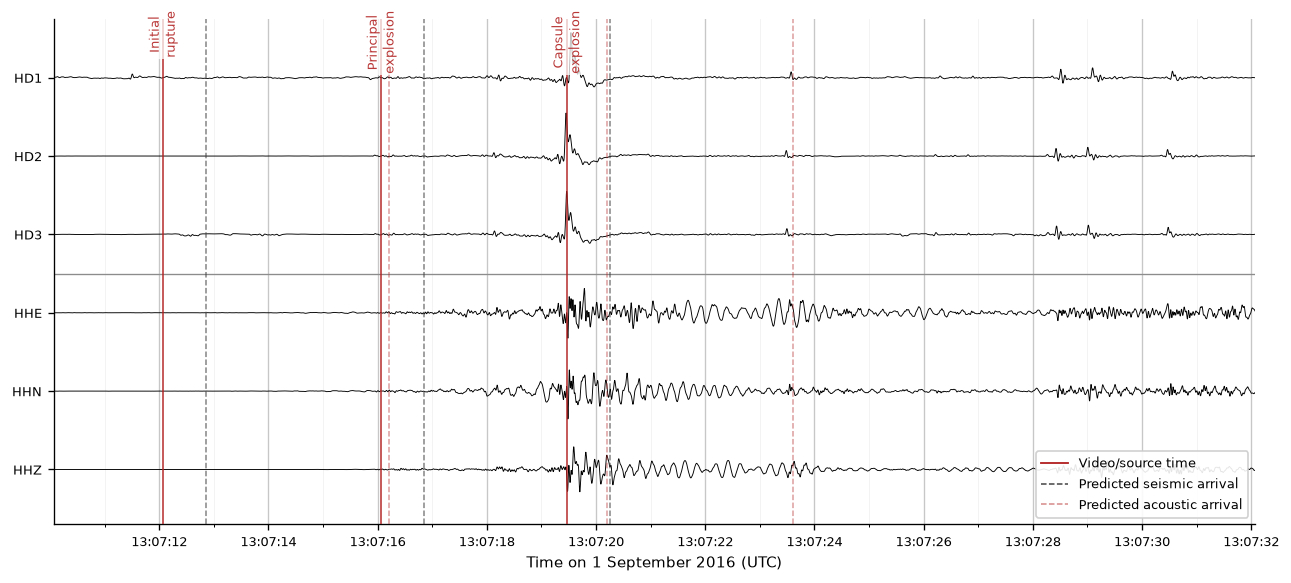

In [43]:
# ---------------------------------------------------------------------
# Figure 3 inputs: 20 s zoom of initial explosion sequence
# Edit these values as needed.
# ---------------------------------------------------------------------

SOURCE_TO_BCHH_M = 1420.0
ACOUSTIC_SPEED_MPS = 343.0
SEISMIC_SPEED_MPS = 1800.0

ZOOM_START = EXPLOSION_TIME - 2
ZOOM_END = EXPLOSION_TIME + 20

SOURCE_EVENTS = {
    "Initial\nrupture": EXPLOSION_TIME,
    "Principal\nexplosion": EXPLOSION_TIME + 4.0,
    # Replace with final video-derived timing:
    "Capsule\nexplosion": EXPLOSION_TIME + 7.4,
}

SHOW_SOURCE_TIMES = True
SHOW_SEISMIC_ARRIVALS = True
SHOW_ACOUSTIC_ARRIVALS = True


def make_zoom_figure(
    st: Stream,
    outfile_base: Path,
    zoom_start: UTCDateTime,
    zoom_end: UTCDateTime,
    source_events: dict,
    source_to_station_m: float,
    acoustic_speed_mps: float,
    seismic_speed_mps: float,
    show_source_times: bool = True,
    show_seismic_arrivals: bool = True,
    show_acoustic_arrivals: bool = True,
    normalize_by_group: bool = False,
    clip: float = 4.0,
    trace_gain: float = 0.18,
):
    """
    Expanded view of the first ~20 s of the Falcon 9 explosion sequence.

    Solid red lines = video/source times.
    Dashed gray lines = predicted seismic arrivals at BCHH.
    Dashed red lines = predicted acoustic arrivals at BCHH.
    """
    n = len(st)
    if n == 0:
        raise ValueError("No traces to plot")

    fig, ax = plt.subplots(figsize=(11.0, 5.2))

    offsets = np.arange(n)[::-1].astype(float)
    channel_labels = []

    infra_scales, seis_scales = [], []
    for tr in st:
        s = robust_scale(tr.data, percentile=99.5)
        if is_infrasound_channel(tr.stats.channel):
            infra_scales.append(s)
        else:
            seis_scales.append(s)

    group_scale_infra = np.median(infra_scales) if infra_scales else 1.0
    group_scale_seis = np.median(seis_scales) if seis_scales else 1.0

    for i, tr in enumerate(st):
        y0 = offsets[i]
        ch = tr.stats.channel.upper()

        trc = tr.copy().trim(zoom_start, zoom_end, pad=True, fill_value=0)
        t = trace_time_array_datetime64(trc)

        data = trc.data.astype(float)
        data = np.nan_to_num(data, nan=0.0, posinf=0.0, neginf=0.0)

        if normalize_by_group:
            scale = group_scale_infra if is_infrasound_channel(ch) else group_scale_seis
        else:
            scale = robust_scale(data, percentile=99.5)

        if not np.isfinite(scale) or scale <= 0:
            scale = 1.0

        y = y0 + np.clip(data / scale, -clip, clip) * trace_gain
        ax.plot(t, y, "-", color="black", lw=0.55, rasterized=True)

        channel_labels.append(ch)

    ax.set_yticks(offsets)
    ax.set_yticklabels(channel_labels)
    ax.set_ylim(-0.7, n - 0.25)

    ax.set_xlim(
        mdates.date2num(zoom_start.datetime),
        mdates.date2num(zoom_end.datetime),
    )

    ax.xaxis.set_major_locator(mdates.SecondLocator(interval=2))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M:%S"))
    ax.xaxis.set_minor_locator(mdates.SecondLocator(interval=1))

    ax.grid(axis="x", which="major", color="0.78", lw=0.8)
    ax.grid(axis="x", which="minor", color="0.93", lw=0.4)

    ax.set_xlabel("Time on 1 September 2016 (UTC)")

    if n >= 6:
        ax.axhline(2.5, color="0.55", lw=0.8)

    ytop = n - 0.15

    for label, tt in source_events.items():

        # Solid red video/source time
        if show_source_times and zoom_start <= tt <= zoom_end:
            x = mdates.date2num(tt.datetime)
            ax.axvline(x, color="firebrick", lw=1.1, alpha=0.80, zorder=20)
            ax.text(
                x,
                ytop,
                label,
                rotation=90,
                ha="center",
                va="top",
                fontsize=8,
                color="firebrick",
                alpha=0.90,
                bbox=dict(facecolor="white", edgecolor="none", alpha=0.75, pad=1.0),
                clip_on=False,
                zorder=25,
            )

        # Dashed gray predicted seismic arrival
        if show_seismic_arrivals:
            t_seis = tt + source_to_station_m / seismic_speed_mps
            if zoom_start <= t_seis <= zoom_end:
                xs = mdates.date2num(t_seis.datetime)
                ax.axvline(xs, color="0.25", lw=0.9, ls="--", alpha=0.65, zorder=15)

        # Dashed red predicted acoustic arrival
        if show_acoustic_arrivals:
            t_ac = tt + source_to_station_m / acoustic_speed_mps
            if zoom_start <= t_ac <= zoom_end:
                xa = mdates.date2num(t_ac.datetime)
                ax.axvline(xa, color="firebrick", lw=0.9, ls="--", alpha=0.45, zorder=15)

    # Minimal legend for line meanings
    handles = [
        plt.Line2D([], [], color="firebrick", lw=1.1, label="Video/source time"),
        plt.Line2D([], [], color="0.25", lw=0.9, ls="--", label="Predicted seismic arrival"),
        plt.Line2D([], [], color="firebrick", lw=0.9, ls="--", alpha=0.55, label="Predicted acoustic arrival"),
    ]
    ax.legend(handles=handles, loc="lower right", fontsize=8, framealpha=0.9)

    for spine in ["top", "right"]:
        ax.spines[spine].set_visible(False)

    fig.subplots_adjust(left=0.08, right=0.99, top=0.96, bottom=0.15)

    for ext in ["png", "pdf"]:
        fig.savefig(
            outfile_base.with_suffix(f".{ext}"),
            dpi=300,
            bbox_inches="tight",
            pad_inches=0.04,
        )

    return fig, ax


fig, ax = make_zoom_figure(
    st_plot2,
    OUTDIR / "fig03_bchh_20s_zoom",
    ZOOM_START,
    ZOOM_END,
    source_events=SOURCE_EVENTS,
    source_to_station_m=SOURCE_TO_BCHH_M,
    acoustic_speed_mps=ACOUSTIC_SPEED_MPS,
    seismic_speed_mps=SEISMIC_SPEED_MPS,
    show_source_times=SHOW_SOURCE_TIMES,
    show_seismic_arrivals=SHOW_SEISMIC_ARRIVALS,
    show_acoustic_arrivals=SHOW_ACOUSTIC_ARRIVALS,
    normalize_by_group=False,
    clip=4.0,
    trace_gain=0.18,
)

plt.show()

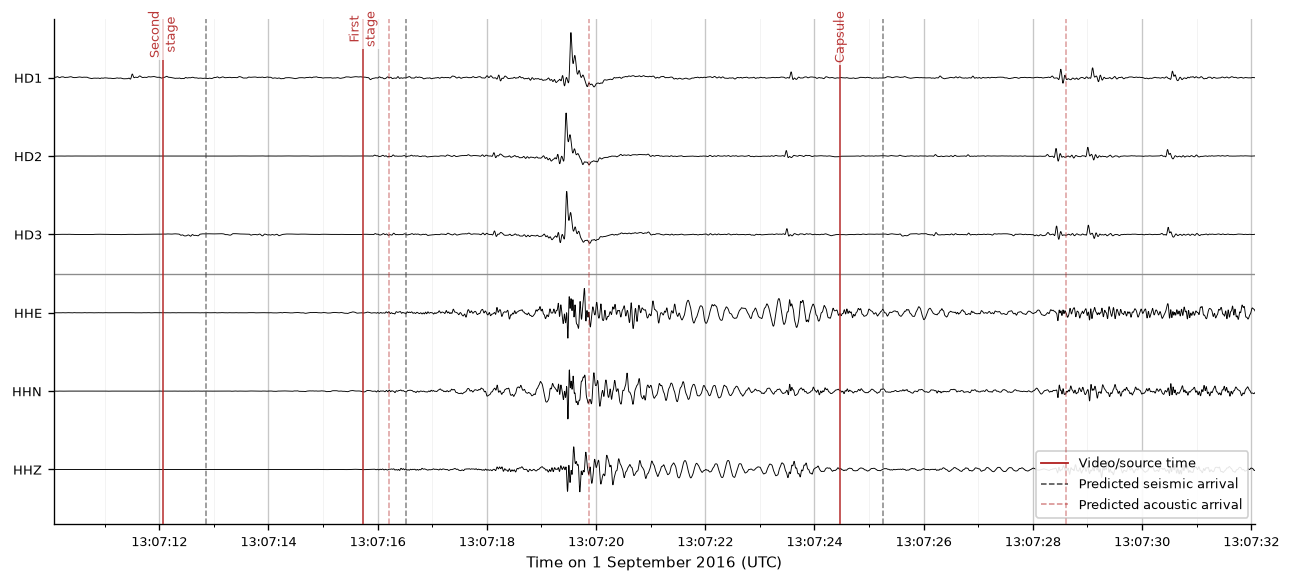

In [ ]:
# ---------------------------------------------------------------------
# Figure 3 inputs: 20 s zoom of initial explosion sequence
# Edit these values as needed.
# ---------------------------------------------------------------------

SOURCE_TO_BCHH_M = 1420.0
ACOUSTIC_SPEED_MPS = 343.0
SEISMIC_SPEED_MPS = 1100.0

ZOOM_START = EXPLOSION_TIME - 2
ZOOM_END = EXPLOSION_TIME + 20

FIRST_STAGE = UTCDateTime("2016-09-01T13:07:15.000")+22*1/30
CAPSULE = UTCDateTime("2016-09-01T13:07:24.000")+14*1/30

SOURCE_EVENTS = {
    "Second\nstage": EXPLOSION_TIME,
    "First\nstage": FIRST_STAGE,
    "Capsule": CAPSULE
}

SHOW_SOURCE_TIMES = True
SHOW_SEISMIC_ARRIVALS = True
SHOW_ACOUSTIC_ARRIVALS = True


def make_zoom_figure(
    st: Stream,
    outfile_base: Path,
    zoom_start: UTCDateTime,
    zoom_end: UTCDateTime,
    source_events: dict,
    source_to_station_m: float,
    acoustic_speed_mps: float,
    seismic_speed_mps: float,
    show_source_times: bool = True,
    show_seismic_arrivals: bool = True,
    show_acoustic_arrivals: bool = True,
    normalize_by_group: bool = False,
    clip: float = 4.0,
    trace_gain: float = 0.18,
):
    """
    Expanded view of the first ~20 s of the Falcon 9 explosion sequence.

    Solid red lines = video/source times.
    Dashed gray lines = predicted seismic arrivals at BCHH.
    Dashed red lines = predicted acoustic arrivals at BCHH.
    """
    n = len(st)
    if n == 0:
        raise ValueError("No traces to plot")

    fig, ax = plt.subplots(figsize=(11.0, 5.2))

    offsets = np.arange(n)[::-1].astype(float)
    channel_labels = []

    infra_scales, seis_scales = [], []
    for tr in st:
        s = robust_scale(tr.data, percentile=99.5)
        if is_infrasound_channel(tr.stats.channel):
            infra_scales.append(s)
        else:
            seis_scales.append(s)

    group_scale_infra = np.median(infra_scales) if infra_scales else 1.0
    group_scale_seis = np.median(seis_scales) if seis_scales else 1.0

    for i, tr in enumerate(st):
        y0 = offsets[i]
        ch = tr.stats.channel.upper()

        trc = tr.copy().trim(zoom_start, zoom_end, pad=True, fill_value=0)
        t = trace_time_array_datetime64(trc)

        data = trc.data.astype(float)
        data = np.nan_to_num(data, nan=0.0, posinf=0.0, neginf=0.0)

        if normalize_by_group:
            scale = group_scale_infra if is_infrasound_channel(ch) else group_scale_seis
        else:
            scale = robust_scale(data, percentile=99.5)

        if not np.isfinite(scale) or scale <= 0:
            scale = 1.0

        y = y0 + np.clip(data / scale, -clip, clip) * trace_gain
        ax.plot(t, y, "-", color="black", lw=0.55, rasterized=True)

        channel_labels.append(ch)

    ax.set_yticks(offsets)
    ax.set_yticklabels(channel_labels)
    ax.set_ylim(-0.7, n - 0.25)

    ax.set_xlim(
        mdates.date2num(zoom_start.datetime),
        mdates.date2num(zoom_end.datetime),
    )

    ax.xaxis.set_major_locator(mdates.SecondLocator(interval=2))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M:%S"))
    ax.xaxis.set_minor_locator(mdates.SecondLocator(interval=1))

    ax.grid(axis="x", which="major", color="0.78", lw=0.8)
    ax.grid(axis="x", which="minor", color="0.93", lw=0.4)

    ax.set_xlabel("Time on 1 September 2016 (UTC)")

    if n >= 6:
        ax.axhline(2.5, color="0.55", lw=0.8)

    ytop = n - 0.15

    for label, tt in source_events.items():

        # Solid red video/source time
        if show_source_times and zoom_start <= tt <= zoom_end:
            x = mdates.date2num(tt.datetime)
            ax.axvline(x, color="firebrick", lw=1.1, alpha=0.80, zorder=20)
            ax.text(
                x,
                ytop,
                label,
                rotation=90,
                ha="center",
                va="top",
                fontsize=8,
                color="firebrick",
                alpha=0.90,
                bbox=dict(facecolor="white", edgecolor="none", alpha=0.75, pad=1.0),
                clip_on=False,
                zorder=25,
            )

        # Dashed gray predicted seismic arrival
        if show_seismic_arrivals:
            t_seis = tt + source_to_station_m / seismic_speed_mps
            if zoom_start <= t_seis <= zoom_end:
                xs = mdates.date2num(t_seis.datetime)
                ax.axvline(xs, color="0.25", lw=0.9, ls="--", alpha=0.65, zorder=15)

        # Dashed red predicted acoustic arrival
        if show_acoustic_arrivals:
            t_ac = tt + source_to_station_m / acoustic_speed_mps
            if zoom_start <= t_ac <= zoom_end:
                xa = mdates.date2num(t_ac.datetime)
                ax.axvline(xa, color="firebrick", lw=0.9, ls="--", alpha=0.45, zorder=15)

    # Minimal legend for line meanings
    handles = [
        plt.Line2D([], [], color="firebrick", lw=1.1, label="Video/source time"),
        plt.Line2D([], [], color="0.25", lw=0.9, ls="--", label="Predicted seismic arrival"),
        plt.Line2D([], [], color="firebrick", lw=0.9, ls="--", alpha=0.55, label="Predicted acoustic arrival"),
    ]
    ax.legend(handles=handles, loc="lower right", fontsize=8, framealpha=0.9)

    for spine in ["top", "right"]:
        ax.spines[spine].set_visible(False)

    fig.subplots_adjust(left=0.08, right=0.99, top=0.96, bottom=0.15)

    for ext in ["png", "pdf"]:
        fig.savefig(
            outfile_base.with_suffix(f".{ext}"),
            dpi=300,
            bbox_inches="tight",
            pad_inches=0.04,
        )

    return fig, ax


fig, ax = make_zoom_figure(
    st_plot2,
    OUTDIR / "fig03_bchh_20s_zoom",
    ZOOM_START,
    ZOOM_END,
    source_events=SOURCE_EVENTS,
    source_to_station_m=SOURCE_TO_BCHH_M,
    acoustic_speed_mps=ACOUSTIC_SPEED_MPS,
    seismic_speed_mps=SEISMIC_SPEED_MPS,
    show_source_times=SHOW_SOURCE_TIMES,
    show_seismic_arrivals=SHOW_SEISMIC_ARRIVALS,
    show_acoustic_arrivals=SHOW_ACOUSTIC_ARRIVALS,
    normalize_by_group=False,
    clip=4.0,
    trace_gain=0.18,
)

plt.show()

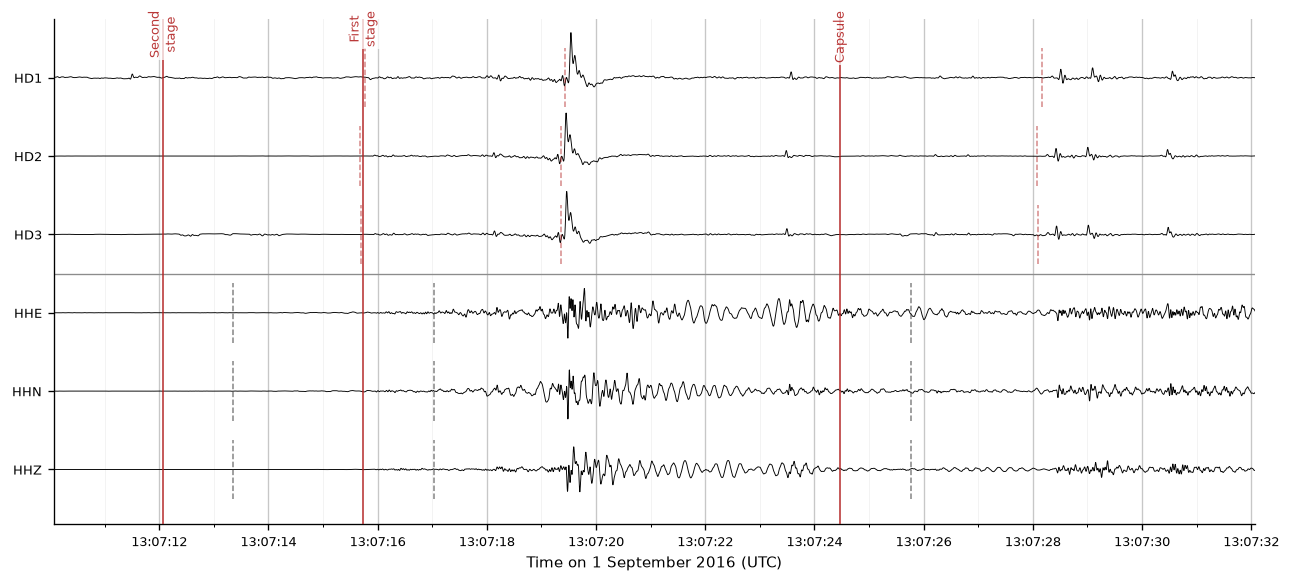

In [49]:
# ---------------------------------------------------------------------
# Figure 3 inputs: 20 s zoom of initial explosion sequence
# Edit these values as needed.
# ---------------------------------------------------------------------

ACOUSTIC_SPEED_MPS = 390#350.4
SEISMIC_SPEED_MPS = 1100.0

SENSOR_DISTANCES_M = {
    "HHE": 1421.8,
    "HHN": 1421.8,
    "HHZ": 1421.8,
    "HD1": 1442.2,
    "HD2": 1410.2,
    "HD3": 1414.8,
}

ZOOM_START = EXPLOSION_TIME - 2
ZOOM_END = EXPLOSION_TIME + 20

FIRST_STAGE = UTCDateTime("2016-09-01T13:07:15.000") + 22 / 30
CAPSULE = UTCDateTime("2016-09-01T13:07:24.000") + 14 / 30

SOURCE_EVENTS = {
    "Second\nstage": EXPLOSION_TIME,
    "First\nstage": FIRST_STAGE,
    "Capsule": CAPSULE,
}

SHOW_SOURCE_TIMES = True
SHOW_SEISMIC_ARRIVALS = True
SHOW_ACOUSTIC_ARRIVALS = True


def make_zoom_figure(
    st: Stream,
    outfile_base: Path,
    zoom_start: UTCDateTime,
    zoom_end: UTCDateTime,
    source_events: dict,
    sensor_distances_m: dict,
    acoustic_speed_mps: float,
    seismic_speed_mps: float,
    show_source_times: bool = True,
    show_seismic_arrivals: bool = True,
    show_acoustic_arrivals: bool = True,
    normalize_by_group: bool = False,
    clip: float = 4.0,
    trace_gain: float = 0.18,
):
    """
    Expanded view of the first ~20 s of the Falcon 9 explosion sequence.

    Solid red lines = video/source times.
    Dashed gray ticks = predicted seismic arrivals at each seismic channel.
    Dashed red ticks = predicted acoustic arrivals at each infrasound channel.
    """
    n = len(st)
    if n == 0:
        raise ValueError("No traces to plot")

    fig, ax = plt.subplots(figsize=(11.0, 5.2))

    offsets = np.arange(n)[::-1].astype(float)
    channel_labels = []
    channel_y = {}

    infra_scales, seis_scales = [], []
    for tr in st:
        s = robust_scale(tr.data, percentile=99.5)
        if is_infrasound_channel(tr.stats.channel):
            infra_scales.append(s)
        else:
            seis_scales.append(s)

    group_scale_infra = np.median(infra_scales) if infra_scales else 1.0
    group_scale_seis = np.median(seis_scales) if seis_scales else 1.0

    for i, tr in enumerate(st):
        y0 = offsets[i]
        ch = tr.stats.channel.upper()
        channel_y[ch] = y0

        trc = tr.copy().trim(zoom_start, zoom_end, pad=True, fill_value=0)
        t = trace_time_array_datetime64(trc)

        data = trc.data.astype(float)
        data = np.nan_to_num(data, nan=0.0, posinf=0.0, neginf=0.0)

        if normalize_by_group:
            scale = group_scale_infra if is_infrasound_channel(ch) else group_scale_seis
        else:
            scale = robust_scale(data, percentile=99.5)

        if not np.isfinite(scale) or scale <= 0:
            scale = 1.0

        y = y0 + np.clip(data / scale, -clip, clip) * trace_gain
        ax.plot(t, y, "-", color="black", lw=0.55, rasterized=True)

        channel_labels.append(ch)

    ax.set_yticks(offsets)
    ax.set_yticklabels(channel_labels)

    separator_y = 2.5
    ymin, ymax = -0.7, n - 0.25
    ax.set_ylim(ymin, ymax)

    ax.set_xlim(
        mdates.date2num(zoom_start.datetime),
        mdates.date2num(zoom_end.datetime),
    )

    ax.xaxis.set_major_locator(mdates.SecondLocator(interval=2))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M:%S"))
    ax.xaxis.set_minor_locator(mdates.SecondLocator(interval=1))

    ax.grid(axis="x", which="major", color="0.78", lw=0.8)
    ax.grid(axis="x", which="minor", color="0.93", lw=0.4)

    ax.set_xlabel("Time on 1 September 2016 (UTC)")

    if n >= 6:
        ax.axhline(separator_y, color="0.55", lw=0.8)

    def draw_channel_vline(x, y0, half_height=0.38, **kwargs):
        ax.vlines(x, y0 - half_height, y0 + half_height, **kwargs)

    ytop = n - 0.15

    for label, tt in source_events.items():

        # Solid red video/source time: full-height because this is not an arrival.
        if show_source_times and zoom_start <= tt <= zoom_end:
            x = mdates.date2num(tt.datetime)
            ax.axvline(x, color="firebrick", lw=1.1, alpha=0.80, zorder=20)
            ax.text(
                x,
                ytop,
                label,
                rotation=90,
                ha="center",
                va="top",
                fontsize=8,
                color="firebrick",
                alpha=0.90,
                bbox=dict(facecolor="white", edgecolor="none", alpha=0.75, pad=1.0),
                clip_on=False,
                zorder=25,
            )

        # Dashed gray predicted seismic arrivals: seismic channels only.
        if show_seismic_arrivals:
            for ch in ["HHE", "HHN", "HHZ"]:
                if ch not in channel_y or ch not in sensor_distances_m:
                    continue

                t_seis = tt + sensor_distances_m[ch] / seismic_speed_mps
                if zoom_start <= t_seis <= zoom_end:
                    xs = mdates.date2num(t_seis.datetime)
                    draw_channel_vline(
                        xs,
                        channel_y[ch],
                        color="0.25",
                        lw=0.9,
                        linestyles="--",
                        alpha=0.65,
                        zorder=15,
                    )

        # Dashed red predicted acoustic arrivals: infrasound channels only.
        if show_acoustic_arrivals:
            for ch in ["HD1", "HD2", "HD3"]:
                if ch not in channel_y or ch not in sensor_distances_m:
                    continue

                t_ac = tt + sensor_distances_m[ch] / acoustic_speed_mps
                if zoom_start <= t_ac <= zoom_end:
                    xa = mdates.date2num(t_ac.datetime)
                    draw_channel_vline(
                        xa,
                        channel_y[ch],
                        color="firebrick",
                        lw=0.9,
                        linestyles="--",
                        alpha=0.55,
                        zorder=15,
                    )

    handles = [
        plt.Line2D([], [], color="firebrick", lw=1.1, label="Video/source time"),
        plt.Line2D([], [], color="0.25", lw=0.9, ls="--", label="Predicted seismic arrival"),
        plt.Line2D([], [], color="firebrick", lw=0.9, ls="--", alpha=0.55, label="Predicted acoustic arrival"),
    ]
    #ax.legend(handles=handles, loc="lower right", fontsize=8, framealpha=0.9)

    for spine in ["top", "right"]:
        ax.spines[spine].set_visible(False)

    fig.subplots_adjust(left=0.08, right=0.99, top=0.96, bottom=0.15)

    for ext in ["png", "pdf"]:
        fig.savefig(
            outfile_base.with_suffix(f".{ext}"),
            dpi=300,
            bbox_inches="tight",
            pad_inches=0.04,
        )

    return fig, ax


fig, ax = make_zoom_figure(
    st_plot2,
    OUTDIR / "fig03_bchh_20s_zoom",
    ZOOM_START,
    ZOOM_END,
    source_events=SOURCE_EVENTS,
    sensor_distances_m=SENSOR_DISTANCES_M,
    acoustic_speed_mps=ACOUSTIC_SPEED_MPS,
    seismic_speed_mps=SEISMIC_SPEED_MPS,
    show_source_times=SHOW_SOURCE_TIMES,
    show_seismic_arrivals=SHOW_SEISMIC_ARRIVALS,
    show_acoustic_arrivals=SHOW_ACOUSTIC_ARRIVALS,
    normalize_by_group=False,
    clip=4.0,
    trace_gain=0.18,
)

plt.show()

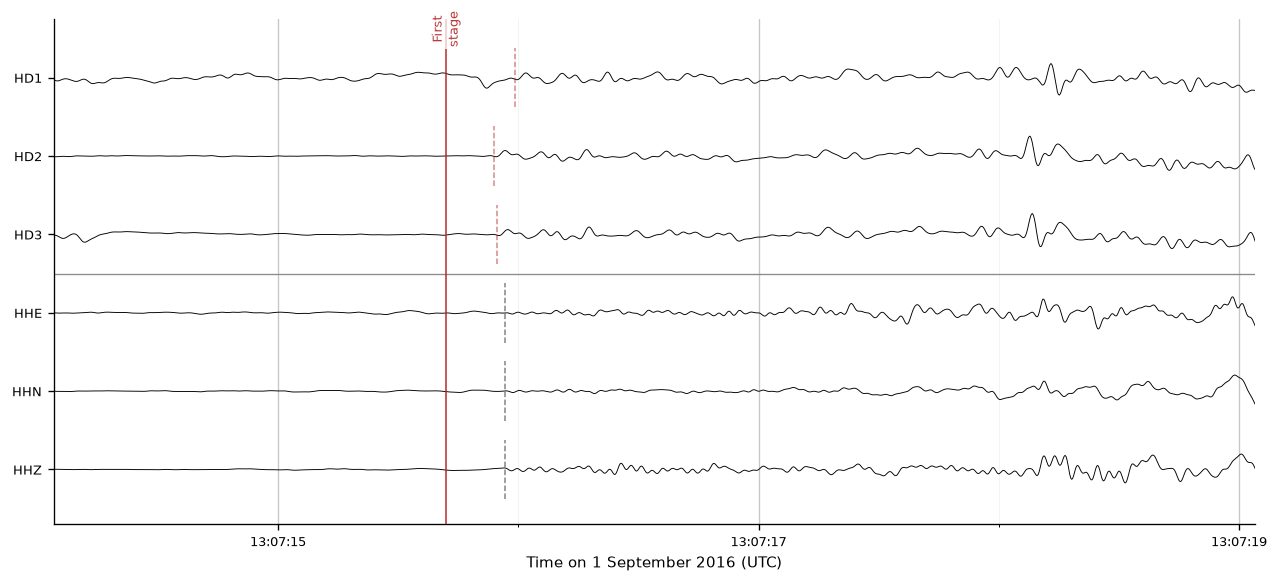

In [71]:
# ---------------------------------------------------------------------
# Figure 3 inputs: 20 s zoom of initial explosion sequence
# Edit these values as needed.
# ---------------------------------------------------------------------

# Display window
ZOOM_START = EXPLOSION_TIME + 2
ZOOM_END = EXPLOSION_TIME + 7

# Source/event times from video
FIRST_STAGE = UTCDateTime("2016-09-01T13:07:15.000") + 21 / 30
CAPSULE = UTCDateTime("2016-09-01T13:07:24.000") + 14 / 30

# Per-event source definitions.
# acoustic_speed_mps is the path-averaged propagation speed used only
# for predicted infrasound arrivals.
SOURCE_EVENTS = {
    "Second\nstage": {
        "time": EXPLOSION_TIME,
        "acoustic_speed_mps": 368,
    },
    "First\nstage": {
        "time": FIRST_STAGE,
        "acoustic_speed_mps": 386,
    },
    "Capsule": {
        "time": CAPSULE,
        "acoustic_speed_mps": 360,
    },
}

# Sensor-specific source-to-receiver distances.
# HH* use the seismometer distance; HD* use individual infrasound distances.
SENSOR_DISTANCES_M = {
    "HHE": 1421.8,
    "HHN": 1421.8,
    "HHZ": 1421.8,
    "HD1": 1442.2,
    "HD2": 1410.2,
    "HD3": 1414.8,
}

# Seismic prediction is optional and uses one apparent speed for HH* channels.
SEISMIC_SPEED_MPS = 5800.0

SHOW_SOURCE_TIMES = True
SHOW_SEISMIC_ARRIVALS = True
SHOW_ACOUSTIC_ARRIVALS = True
SHOW_LEGEND = False


def make_zoom_figure(
    st: Stream,
    outfile_base: Path,
    zoom_start: UTCDateTime,
    zoom_end: UTCDateTime,
    source_events: dict,
    sensor_distances_m: dict,
    seismic_speed_mps: float,
    show_source_times: bool = True,
    show_seismic_arrivals: bool = True,
    show_acoustic_arrivals: bool = True,
    show_legend: bool = False,
    normalize_by_group: bool = False,
    clip: float = 4.0,
    trace_gain: float = 0.18,
):
    """
    Expanded view of the first ~20 s of the Falcon 9 explosion sequence.

    Solid red lines = video/source times.
    Dashed red ticks = predicted acoustic arrivals on HD* channels using
                       event-specific average acoustic/blast speeds.
    Dashed gray ticks = predicted seismic arrivals on HH* channels using
                        seismic_speed_mps.
    """
    n = len(st)
    if n == 0:
        raise ValueError("No traces to plot")

    fig, ax = plt.subplots(figsize=(11.0, 5.2))

    offsets = np.arange(n)[::-1].astype(float)
    channel_labels = []
    channel_y = {}

    infra_scales, seis_scales = [], []
    for tr in st:
        s = robust_scale(tr.data, percentile=99.5)
        if is_infrasound_channel(tr.stats.channel):
            infra_scales.append(s)
        else:
            seis_scales.append(s)

    group_scale_infra = np.median(infra_scales) if infra_scales else 1.0
    group_scale_seis = np.median(seis_scales) if seis_scales else 1.0

    for i, tr in enumerate(st):
        y0 = offsets[i]
        ch = tr.stats.channel.upper()
        channel_y[ch] = y0

        trc = tr.copy().trim(zoom_start, zoom_end, pad=True, fill_value=0)
        t = trace_time_array_datetime64(trc)

        data = trc.data.astype(float)
        data = np.nan_to_num(data, nan=0.0, posinf=0.0, neginf=0.0)

        if normalize_by_group:
            scale = group_scale_infra if is_infrasound_channel(ch) else group_scale_seis
        else:
            scale = robust_scale(data, percentile=99.5)

        if not np.isfinite(scale) or scale <= 0:
            scale = 1.0

        y = y0 + np.clip(data / scale, -clip, clip) * trace_gain
        ax.plot(t, y, "-", color="black", lw=0.55, rasterized=True)

        channel_labels.append(ch)

    ax.set_yticks(offsets)
    ax.set_yticklabels(channel_labels)

    separator_y = 2.5
    ymin, ymax = -0.7, n - 0.25
    ax.set_ylim(ymin, ymax)

    ax.set_xlim(
        mdates.date2num(zoom_start.datetime),
        mdates.date2num(zoom_end.datetime),
    )

    ax.xaxis.set_major_locator(mdates.SecondLocator(interval=2))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M:%S"))
    ax.xaxis.set_minor_locator(mdates.SecondLocator(interval=1))

    ax.grid(axis="x", which="major", color="0.78", lw=0.8)
    ax.grid(axis="x", which="minor", color="0.93", lw=0.4)

    ax.set_xlabel("Time on 1 September 2016 (UTC)")

    if n >= 6:
        ax.axhline(separator_y, color="0.55", lw=0.8)

    def draw_channel_vline(x, y0, half_height=0.38, **kwargs):
        ax.vlines(x, y0 - half_height, y0 + half_height, **kwargs)

    ytop = n - 0.15

    for label, event in source_events.items():
        tt = event["time"]
        acoustic_speed_mps = event.get("acoustic_speed_mps", None)

        # Solid red video/source time: full-height because this is not an arrival.
        if show_source_times and zoom_start <= tt <= zoom_end:
            x = mdates.date2num(tt.datetime)
            ax.axvline(x, color="firebrick", lw=1.1, alpha=0.80, zorder=20)
            ax.text(
                x,
                ytop,
                label,
                rotation=90,
                ha="center",
                va="top",
                fontsize=8,
                color="firebrick",
                alpha=0.90,
                bbox=dict(facecolor="white", edgecolor="none", alpha=0.75, pad=1.0),
                clip_on=False,
                zorder=25,
            )

        # Dashed gray predicted seismic arrivals: seismic channels only.
        if show_seismic_arrivals:
            for ch in ["HHE", "HHN", "HHZ"]:
                if ch not in channel_y or ch not in sensor_distances_m:
                    continue

                t_seis = tt + sensor_distances_m[ch] / seismic_speed_mps
                if zoom_start <= t_seis <= zoom_end:
                    xs = mdates.date2num(t_seis.datetime)
                    draw_channel_vline(
                        xs,
                        channel_y[ch],
                        color="0.25",
                        lw=0.9,
                        linestyles="--",
                        alpha=0.65,
                        zorder=15,
                    )

        # Dashed red predicted acoustic arrivals: infrasound channels only.
        # Uses event-specific path-averaged acoustic/blast speed.
        if show_acoustic_arrivals and acoustic_speed_mps is not None:
            for ch in ["HD1", "HD2", "HD3"]:
                if ch not in channel_y or ch not in sensor_distances_m:
                    continue

                t_ac = tt + sensor_distances_m[ch] / acoustic_speed_mps
                if zoom_start <= t_ac <= zoom_end:
                    xa = mdates.date2num(t_ac.datetime)
                    draw_channel_vline(
                        xa,
                        channel_y[ch],
                        color="firebrick",
                        lw=0.9,
                        linestyles="--",
                        alpha=0.55,
                        zorder=15,
                    )

    if show_legend:
        handles = [
            plt.Line2D([], [], color="firebrick", lw=1.1, label="Video/source time"),
            plt.Line2D([], [], color="0.25", lw=0.9, ls="--", label=f"Predicted seismic arrival ({seismic_speed_mps:g} m/s)"),
            plt.Line2D([], [], color="firebrick", lw=0.9, ls="--", alpha=0.55, label="Predicted acoustic arrival"),
        ]
        ax.legend(handles=handles, loc="lower right", fontsize=8, framealpha=0.9)

    for spine in ["top", "right"]:
        ax.spines[spine].set_visible(False)

    fig.subplots_adjust(left=0.08, right=0.99, top=0.96, bottom=0.15)

    for ext in ["png", "pdf"]:
        fig.savefig(
            outfile_base.with_suffix(f".{ext}"),
            dpi=300,
            bbox_inches="tight",
            pad_inches=0.04,
        )

    return fig, ax


fig, ax = make_zoom_figure(
    st_plot2,
    OUTDIR / "fig03_bchh_20s_zoom",
    ZOOM_START,
    ZOOM_END,
    source_events=SOURCE_EVENTS,
    sensor_distances_m=SENSOR_DISTANCES_M,
    seismic_speed_mps=SEISMIC_SPEED_MPS,
    show_source_times=SHOW_SOURCE_TIMES,
    show_seismic_arrivals=SHOW_SEISMIC_ARRIVALS,
    show_acoustic_arrivals=SHOW_ACOUSTIC_ARRIVALS,
    show_legend=SHOW_LEGEND,
    normalize_by_group=False,
    clip=4.0,
    trace_gain=0.18,
)

plt.show()

In [72]:
# ------------------------------------------------------------------
# Compute 3-component vector amplitude and envelope
# ------------------------------------------------------------------

from scipy.signal import hilbert
from obspy import Trace

# Extract aligned seismic traces
st3 = st_plot2.select(channel="HH?").copy()

st3.trim(ZOOM_START, ZOOM_END)

# Make absolutely sure lengths match
n = min(tr.stats.npts for tr in st3)
for tr in st3:
    tr.data = tr.data[:n]

HHE = st3.select(channel="HHE")[0].data.astype(float)
HHN = st3.select(channel="HHN")[0].data.astype(float)
HHZ = st3.select(channel="HHZ")[0].data.astype(float)

# Vector amplitude
vec = np.sqrt(HHE**2 + HHN**2 + HHZ**2)

# Envelope of vector amplitude
vec_env = np.abs(hilbert(vec))

# Create traces for plotting
tr_vec = st3[0].copy()
tr_vec.stats.channel = "VEC"
tr_vec.data = vec

tr_env = st3[0].copy()
tr_env.stats.channel = "ENV"
tr_env.data = vec_env

st_vector = Stream([tr_vec, tr_env])

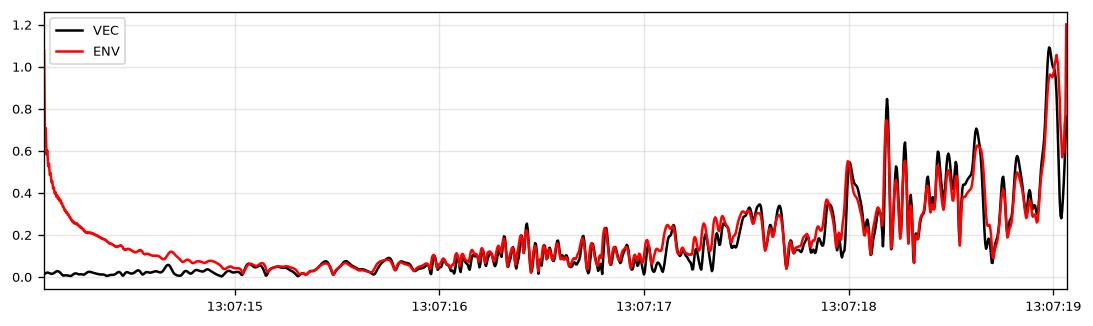

In [73]:
fig, ax = plt.subplots(figsize=(11,3))

for tr, color in zip(st_vector, ["black","red"]):

    t = trace_time_array_datetime64(tr)

    d = tr.data
    d /= np.percentile(d,99.5)

    ax.plot(t,d,label=tr.stats.channel,color=color)

ax.legend()
ax.grid(True,alpha=0.3)

ax.set_xlim(
    mdates.date2num(ZOOM_START.datetime),
    mdates.date2num(ZOOM_END.datetime),
)

ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M:%S"))
ax.xaxis.set_major_locator(mdates.SecondLocator(interval=1))

plt.show()

Figure 3. Expanded view of the first 20 s of response-corrected infrasound and seismic recordings from BCHH. The initial video-timed rupture and principal explosion are marked. Traces are independently scaled for display and clipped to emphasize the timing of impulsive arrivals across the six channels.

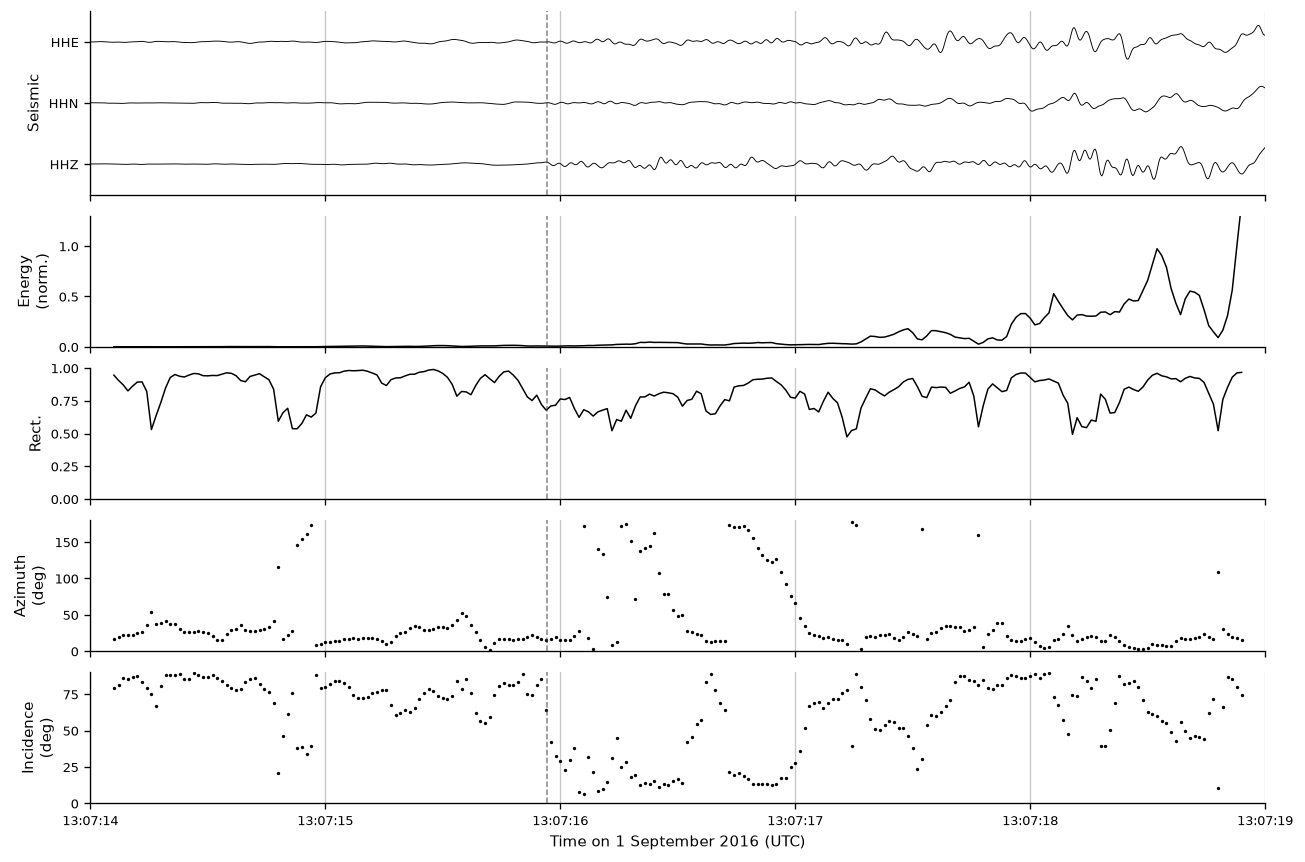

In [75]:
# ------------------------------------------------------------------
# Instantaneous polarization analysis for 3-component seismic data
# ------------------------------------------------------------------

from scipy.signal import hilbert
from numpy.lib.stride_tricks import sliding_window_view

POL_START = UTCDateTime("2016-09-01T13:07:14.0")
POL_END   = UTCDateTime("2016-09-01T13:07:19.0")

POL_WIN_SEC = 0.20       # sliding covariance window
POL_STEP_SEC = 0.02      # output sample spacing
POL_FILTER = (2.0, 25.0) # Hz; adjust as needed

P_WAVE_SPEED_MPS = 5800.0

PREDICTED_P_EVENTS = {
    "First stage": FIRST_STAGE,
    # "Second stage": EXPLOSION_TIME,  # add/remove as useful
}


def get_aligned_3c(st, start, end, channels=("HHE", "HHN", "HHZ")):
    """
    Return aligned E, N, Z arrays and timing metadata.
    """
    st3 = st.select(channel="HH?").copy()
    st3.trim(start, end, pad=True, fill_value=0)

    comps = {}
    for ch in channels:
        sel = st3.select(channel=ch)
        if len(sel) == 0:
            raise ValueError(f"Missing channel {ch}")
        comps[ch] = sel[0]

    sr = comps[channels[0]].stats.sampling_rate
    n = min(comps[ch].stats.npts for ch in channels)

    data = {}
    for ch in channels:
        tr = comps[ch].copy()
        tr.data = tr.data[:n].astype(float)
        data[ch] = tr.data

    t0 = comps[channels[0]].stats.starttime
    return data["HHE"], data["HHN"], data["HHZ"], sr, t0, n


def compute_sliding_polarization(E, N, Z, sr, win_sec=0.20, step_sec=0.02):
    """
    Sliding-window covariance polarization.

    Returns:
      time_offsets: seconds from trace start at window centers
      rectilinearity: 0..1, larger = more linear particle motion
      planarity: 0..1
      azimuth_deg: horizontal azimuth of principal motion, degrees clockwise from north
      incidence_deg: angle from vertical, 0 = vertical, 90 = horizontal
      eig1: largest eigenvalue, proportional to polarized energy
    """
    X = np.vstack([E, N, Z]).T
    X = X - np.nanmean(X, axis=0)

    win = max(5, int(round(win_sec * sr)))
    step = max(1, int(round(step_sec * sr)))

    if X.shape[0] < win:
        raise ValueError("Polarization window longer than data segment")

    windows = sliding_window_view(X, window_shape=(win, 3)).squeeze(axis=1)
    windows = windows[::step]

    nwin = windows.shape[0]
    time_offsets = (np.arange(nwin) * step + win / 2) / sr

    rect = np.full(nwin, np.nan)
    plan = np.full(nwin, np.nan)
    az = np.full(nwin, np.nan)
    inc = np.full(nwin, np.nan)
    eig1 = np.full(nwin, np.nan)

    for i in range(nwin):
        W = windows[i]
        W = W - np.mean(W, axis=0)

        C = np.cov(W, rowvar=False)
        vals, vecs = np.linalg.eigh(C)

        order = np.argsort(vals)[::-1]
        vals = vals[order]
        vecs = vecs[:, order]

        l1, l2, l3 = vals
        if l1 <= 0 or not np.isfinite(l1):
            continue

        # Common polarization attributes
        rect[i] = 1.0 - (l2 + l3) / (2.0 * l1)
        plan[i] = 1.0 - (2.0 * l3) / (l1 + l2)

        v = vecs[:, 0]  # components are E, N, Z

        # Resolve 180-degree ambiguity by forcing upward positive Z if desired
        if v[2] < 0:
            v = -v

        # Azimuth clockwise from north
        az[i] = (np.degrees(np.arctan2(v[0], v[1])) + 360.0) % 180.0

        # Incidence from vertical
        horiz = np.sqrt(v[0] ** 2 + v[1] ** 2)
        inc[i] = np.degrees(np.arctan2(horiz, abs(v[2])))

        eig1[i] = l1

    return time_offsets, rect, plan, az, inc, eig1


# Prepare data
st_pol = st_plot2.copy()
st_pol.trim(POL_START - 2, POL_END + 2)
st_pol.filter("bandpass", freqmin=POL_FILTER[0], freqmax=POL_FILTER[1], corners=4, zerophase=True)

E, N, Z, sr, t0, n = get_aligned_3c(st_pol, POL_START, POL_END)

time_offsets, rect, plan, az, inc, eig1 = compute_sliding_polarization(
    E, N, Z, sr,
    win_sec=POL_WIN_SEC,
    step_sec=POL_STEP_SEC,
)

t_pol = np.array([
    mdates.date2num((t0 + float(dt)).datetime)
    for dt in time_offsets
])

# Normalized polarized energy
eig1_norm = eig1 / np.nanpercentile(eig1, 99.5)


# ------------------------------------------------------------------
# Plot instantaneous polarization diagnostics
# ------------------------------------------------------------------

fig, axes = plt.subplots(
    5, 1,
    figsize=(11, 7.5),
    sharex=True,
    gridspec_kw={"height_ratios": [1.4, 1, 1, 1, 1]},
)

# Top panel: seismic traces, lightly scaled
for tr, offset in zip(
    [st_pol.select(channel="HHE")[0], st_pol.select(channel="HHN")[0], st_pol.select(channel="HHZ")[0]],
    [2, 1, 0],
):
    trc = tr.copy().trim(POL_START, POL_END, pad=True, fill_value=0)
    t = trace_time_array_datetime64(trc)
    d = trc.data.astype(float)
    d = d / robust_scale(d, percentile=99.5)
    axes[0].plot(t, offset + 0.25 * np.clip(d, -4, 4), "k", lw=0.55)

axes[0].set_yticks([2, 1, 0])
axes[0].set_yticklabels(["HHE", "HHN", "HHZ"])
axes[0].set_ylim(-0.5, 2.5)
axes[0].set_ylabel("Seismic")

axes[1].plot(t_pol, eig1_norm, "k", lw=0.9)
axes[1].set_ylabel("Energy\n(norm.)")
axes[1].set_ylim(0, min(1.3, np.nanmax(eig1_norm) * 1.05))

axes[2].plot(t_pol, rect, "k", lw=0.9)
axes[2].set_ylabel("Rect.")
axes[2].set_ylim(0, 1)

axes[3].plot(t_pol, az, "k.", ms=2)
axes[3].set_ylabel("Azimuth\n(deg)")
axes[3].set_ylim(0, 180)

axes[4].plot(t_pol, inc, "k.", ms=2)
axes[4].set_ylabel("Incidence\n(deg)")
axes[4].set_ylim(0, 90)

for ax in axes:
    ax.grid(axis="x", which="major", color="0.78", lw=0.8)
    ax.grid(axis="x", which="minor", color="0.93", lw=0.4)

    for label, tt in PREDICTED_P_EVENTS.items():
        tp = tt + SENSOR_DISTANCES_M["HHZ"] / P_WAVE_SPEED_MPS
        if POL_START <= tp <= POL_END:
            x = mdates.date2num(tp.datetime)
            ax.axvline(x, color="0.25", lw=0.9, ls="--", alpha=0.65)

    for spine in ["top", "right"]:
        ax.spines[spine].set_visible(False)

axes[-1].set_xlim(mdates.date2num(POL_START.datetime), mdates.date2num(POL_END.datetime))
axes[-1].xaxis.set_major_locator(mdates.SecondLocator(interval=1))
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter("%H:%M:%S"))
axes[-1].xaxis.set_minor_locator(mdates.SecondLocator(interval=1))
axes[-1].set_xlabel("Time on 1 September 2016 (UTC)")

fig.subplots_adjust(left=0.10, right=0.99, top=0.98, bottom=0.10, hspace=0.15)

for ext in ["png", "pdf"]:
    fig.savefig(
        OUTDIR / f"fig_diagnostic_polarization.{ext}",
        dpi=300,
        bbox_inches="tight",
        pad_inches=0.04,
    )

plt.show()